# 🛰️ Deteksi Bangunan & Area Permukiman — YOLOv8
**Proyek SIG | Pangalengan, Bandung**

Pipeline lengkap: Setup → Dataset → Training → Evaluasi Lengkap → Analisis Spasial → Simpan ke Drive

---
### Struktur folder Google Drive:
```
MyDrive/SIG_Deteksi_Bangunan/
├── dataset/                ← dataset Roboflow (otomatis)
├── weights/
│   ├── best.pt
│   └── last.pt
├── training_results/       ← semua grafik & metrik
├── tiles/                  ← file .tif dari QGIS (isi manual)
├── tiles_jpg/              ← file .jpg dari QGIS (isi manual)
└── output/                 ← semua hasil akhir (GeoJSON, peta, laporan)
```
> **Jalankan cell dari atas ke bawah secara berurutan.**


---
# BAGIAN 1 — SETUP

## 1.1 — Install Library

In [ ]:
!pip install ultralytics roboflow rasterio geopandas folium shapely -q

import ultralytics, torch
print(f"✅ Ultralytics : {ultralytics.__version__}")
print(f"✅ PyTorch     : {torch.__version__}")
print(f"✅ GPU aktif   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU        : {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  Aktifkan GPU: Runtime > Change runtime type > T4 GPU")


✅ Ultralytics : 8.4.95
✅ PyTorch     : 2.11.0+cu128
✅ GPU aktif   : True
   GPU        : Tesla T4


## 1.2 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive terhubung")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive terhubung


## 1.3 — Setup Path & Buat Struktur Folder

In [ ]:
import os

# ⚠️ Ubah kalau nama folder berbeda
DRIVE_BASE          = '/content/drive/MyDrive/SIG_Deteksi_Bangunan'

DATASET_DIR         = f'{DRIVE_BASE}/dataset'
WEIGHTS_DIR         = f'{DRIVE_BASE}/weights'
TRAINING_RESULT_DIR = f'{DRIVE_BASE}/training_results'
TILES_TIF_DIR       = f'{DRIVE_BASE}/tiles'
TILES_JPG_DIR       = f'{DRIVE_BASE}/tiles_jpg'
OUTPUT_DIR          = f'{DRIVE_BASE}/output'
COLAB_WORK_DIR      = '/content/workspace'

for d in [DRIVE_BASE, DATASET_DIR, WEIGHTS_DIR, TRAINING_RESULT_DIR,
          TILES_TIF_DIR, TILES_JPG_DIR, OUTPUT_DIR, COLAB_WORK_DIR]:
    os.makedirs(d, exist_ok=True)

print("=== STRUKTUR FOLDER ===")
for d in [DATASET_DIR, WEIGHTS_DIR, TRAINING_RESULT_DIR,
          TILES_TIF_DIR, TILES_JPG_DIR, OUTPUT_DIR]:
    label = d.replace(DRIVE_BASE, 'Drive/SIG_Deteksi_Bangunan')
    status = "✅" if os.path.exists(d) else "❌"
    print(f"  {status} {label}")

print(f"\n⚠️  Isi manual sebelum inference:")
print(f"  → tiles/     : file .tif dari QGIS")
print(f"  → tiles_jpg/ : file .jpg dari QGIS")


=== STRUKTUR FOLDER ===
  ✅ Drive/SIG_Deteksi_Bangunan/dataset
  ✅ Drive/SIG_Deteksi_Bangunan/weights
  ✅ Drive/SIG_Deteksi_Bangunan/training_results
  ✅ Drive/SIG_Deteksi_Bangunan/tiles
  ✅ Drive/SIG_Deteksi_Bangunan/tiles_jpg
  ✅ Drive/SIG_Deteksi_Bangunan/output

⚠️  Isi manual sebelum inference:
  → tiles/     : file .tif dari QGIS
  → tiles_jpg/ : file .jpg dari QGIS


---
# BAGIAN 2 — DATASET

## 2.1 — Download Dataset dari Roboflow

In [ ]:
from roboflow import Roboflow
import yaml, shutil

# ⚠️ SESUAIKAN
ROBOFLOW_API_KEY   = "YOUR_ROBOFLOW_API_KEY"
ROBOFLOW_WORKSPACE = "ahmad-yani-s-workspace"
ROBOFLOW_PROJECT   = "pangalengan1"
ROBOFLOW_VERSION   = 2


COLAB_DATASET_DIR = '/content/dataset'

print("⬇️  Download dataset dari Roboflow ke Colab...")
rf      = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
dataset = project.version(ROBOFLOW_VERSION).download("yolov8", location=COLAB_DATASET_DIR)

# Cari data.yaml
yaml_found = None
for root, dirs, files in os.walk(COLAB_DATASET_DIR):
    if 'data.yaml' in files:
        yaml_found = root
        break

if yaml_found is None:
    raise FileNotFoundError("data.yaml tidak ditemukan")

dataset.location = yaml_found
print(f"📄 data.yaml ditemukan: {yaml_found}")

# Copy ke Drive
print("\n📁 Menyalin ke Drive...")
if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)
shutil.copytree(dataset.location, DATASET_DIR)
dataset.location = DATASET_DIR
print(f"✅ Dataset tersimpan: {DATASET_DIR}")

with open(f'{dataset.location}/data.yaml') as f:
    data_yaml = yaml.safe_load(f)

print(f"\n=== data.yaml ===")
print(f"  Kelas : {data_yaml.get('names')}")
print(f"  nc    : {data_yaml.get('nc')}")
print(f"  train : {data_yaml.get('train')}")
print(f"  val   : {data_yaml.get('val')}")


⬇️  Download dataset dari Roboflow ke Colab...
loading Roboflow workspace...
loading Roboflow project...
📄 data.yaml ditemukan: /content/dataset

📁 Menyalin ke Drive...
✅ Dataset tersimpan: /content/drive/MyDrive/SIG_Deteksi_Bangunan/dataset

=== data.yaml ===
  Kelas : ['bangunan']
  nc    : 1
  train : ../train/images
  val   : ../valid/images


## 2.2 — Konversi Polygon → Bounding Box

In [ ]:
import glob

label_dirs = [
    f'{dataset.location}/train/labels',
    f'{dataset.location}/valid/labels',
    f'{dataset.location}/test/labels',
]

converted = skipped = 0
for label_dir in label_dirs:
    if not os.path.exists(label_dir):
        continue
    for label_file in glob.glob(f'{label_dir}/*.txt'):
        new_lines = []
        with open(label_file) as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                skipped += 1
                continue
            class_id = parts[0]
            coords   = list(map(float, parts[1:]))
            if len(coords) == 4:
                new_lines.append(line)
                skipped += 1
                continue
            xs = coords[0::2]; ys = coords[1::2]
            xc = (min(xs)+max(xs))/2; yc = (min(ys)+max(ys))/2
            w  = max(xs)-min(xs);     h  = max(ys)-min(ys)
            new_lines.append(f"{class_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")
            converted += 1
        with open(label_file, 'w') as f:
            f.writelines(new_lines)

print(f"✅ Konversi selesai: {converted} polygon → bbox | {skipped} sudah bbox")


✅ Konversi selesai: 5629 polygon → bbox | 0 sudah bbox


## 2.3 — Visualisasi Sample Dataset

Train: 519 | Valid: 32


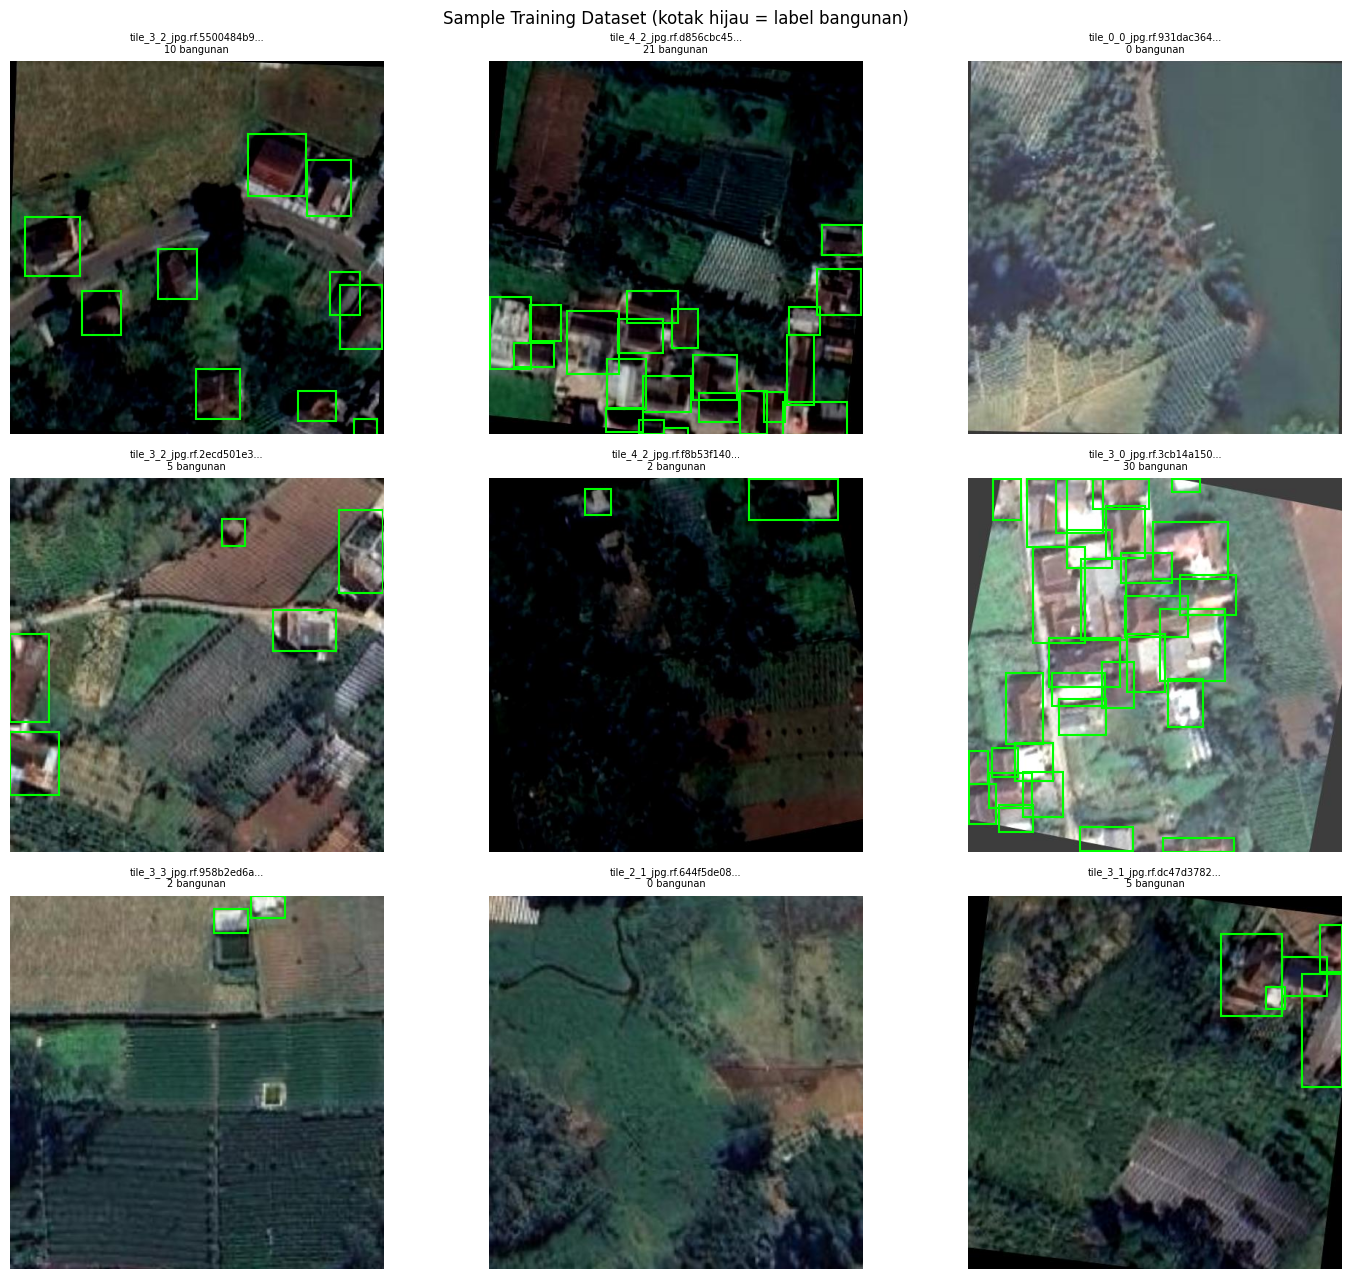

✅ Sample dataset divisualisasikan


In [ ]:
import random, matplotlib.pyplot as plt, matplotlib.patches as patches
from PIL import Image

train_img_dir   = f'{dataset.location}/train/images'
train_label_dir = f'{dataset.location}/train/labels'
val_img_dir     = f'{dataset.location}/valid/images'

all_imgs  = [f for f in os.listdir(train_img_dir) if f.endswith(('.jpg','.png'))]
val_imgs  = [f for f in os.listdir(val_img_dir)   if f.endswith(('.jpg','.png'))]
print(f"Train: {len(all_imgs)} | Valid: {len(val_imgs)}")

sample = random.sample(all_imgs, min(9, len(all_imgs)))
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
axes = axes.flatten()

for idx, img_file in enumerate(sample):
    img  = Image.open(f'{train_img_dir}/{img_file}')
    w, h = img.size
    axes[idx].imshow(img)
    lbl  = f'{train_label_dir}/{img_file.rsplit(".",1)[0]}.txt'
    bbox_count = 0
    if os.path.exists(lbl):
        with open(lbl) as lf:
            for line in lf:
                p = line.strip().split()
                if len(p) < 5: continue
                xc,yc,bw,bh = float(p[1]),float(p[2]),float(p[3]),float(p[4])
                x1=(xc-bw/2)*w; y1=(yc-bh/2)*h
                axes[idx].add_patch(patches.Rectangle(
                    (x1,y1), bw*w, bh*h,
                    linewidth=1.5, edgecolor='lime', facecolor='none'))
                bbox_count += 1
    axes[idx].set_title(f"{img_file[:25]}...\n{bbox_count} bangunan", fontsize=7)
    axes[idx].axis('off')

plt.suptitle('Sample Training Dataset (kotak hijau = label bangunan)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sample_dataset.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Sample dataset divisualisasikan")


## CELL 2.4 — EDA Dataset Komprehensif

     EXPLORATORY DATA ANALYSIS — DATASET

── Tabel Statistik Dataset ──
Split        Gambar     BBox  Tile Kosong  Rata BBox/Tile
-------------------------------------------------------
Train           519     5068          138             9.8
Valid            32      467            8            14.6
Test             11       94            2             8.5
-------------------------------------------------------
Total           562     5629          148            10.0

── Statistik Ukuran Bounding Box (training set, dalam pixel 512x512) ──
  Total bbox     : 5068
  Lebar rata-rata: 55.9 px (min=6, max=282)
  Tinggi rata-rata:58.9 px (min=9, max=260)
  Area rata-rata : 3605 px² (1.4% dari tile)


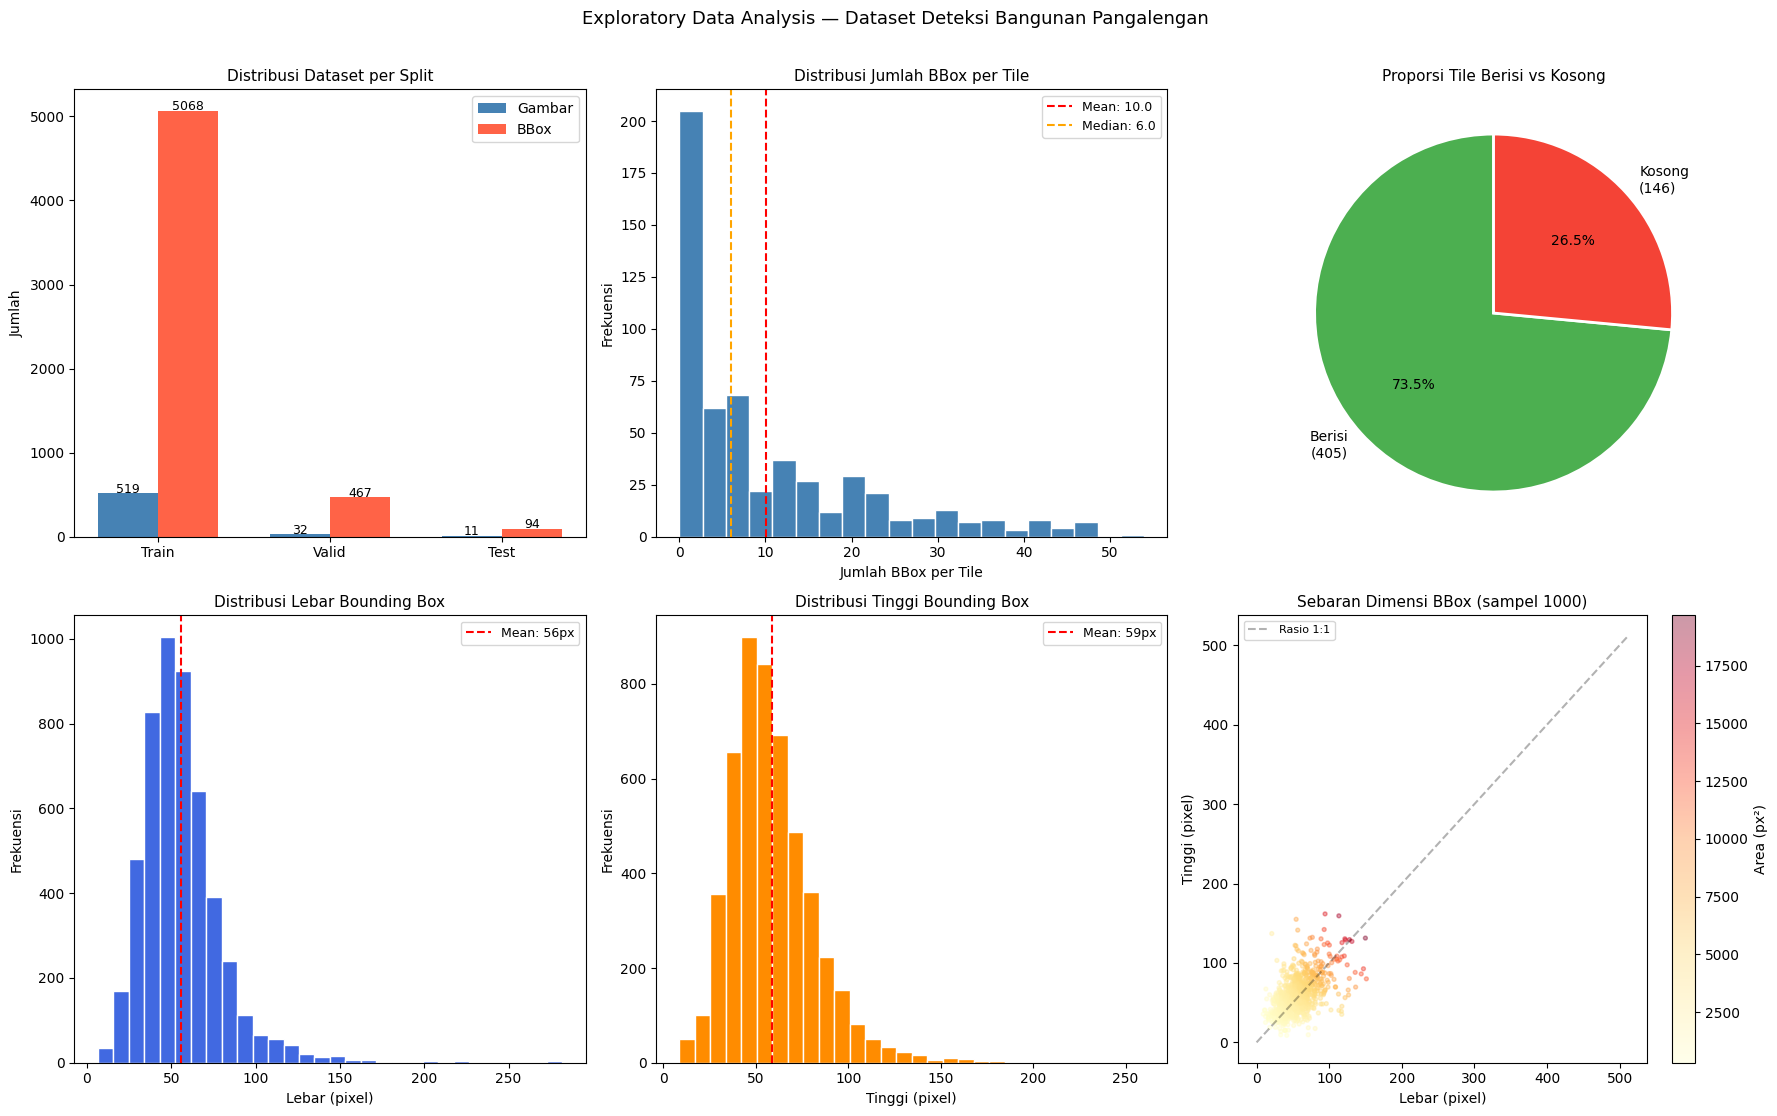

EDA dataset tersimpan: eda_dataset.png

Distribusi posisi & ukuran label di seluruh tile (dari YOLO):


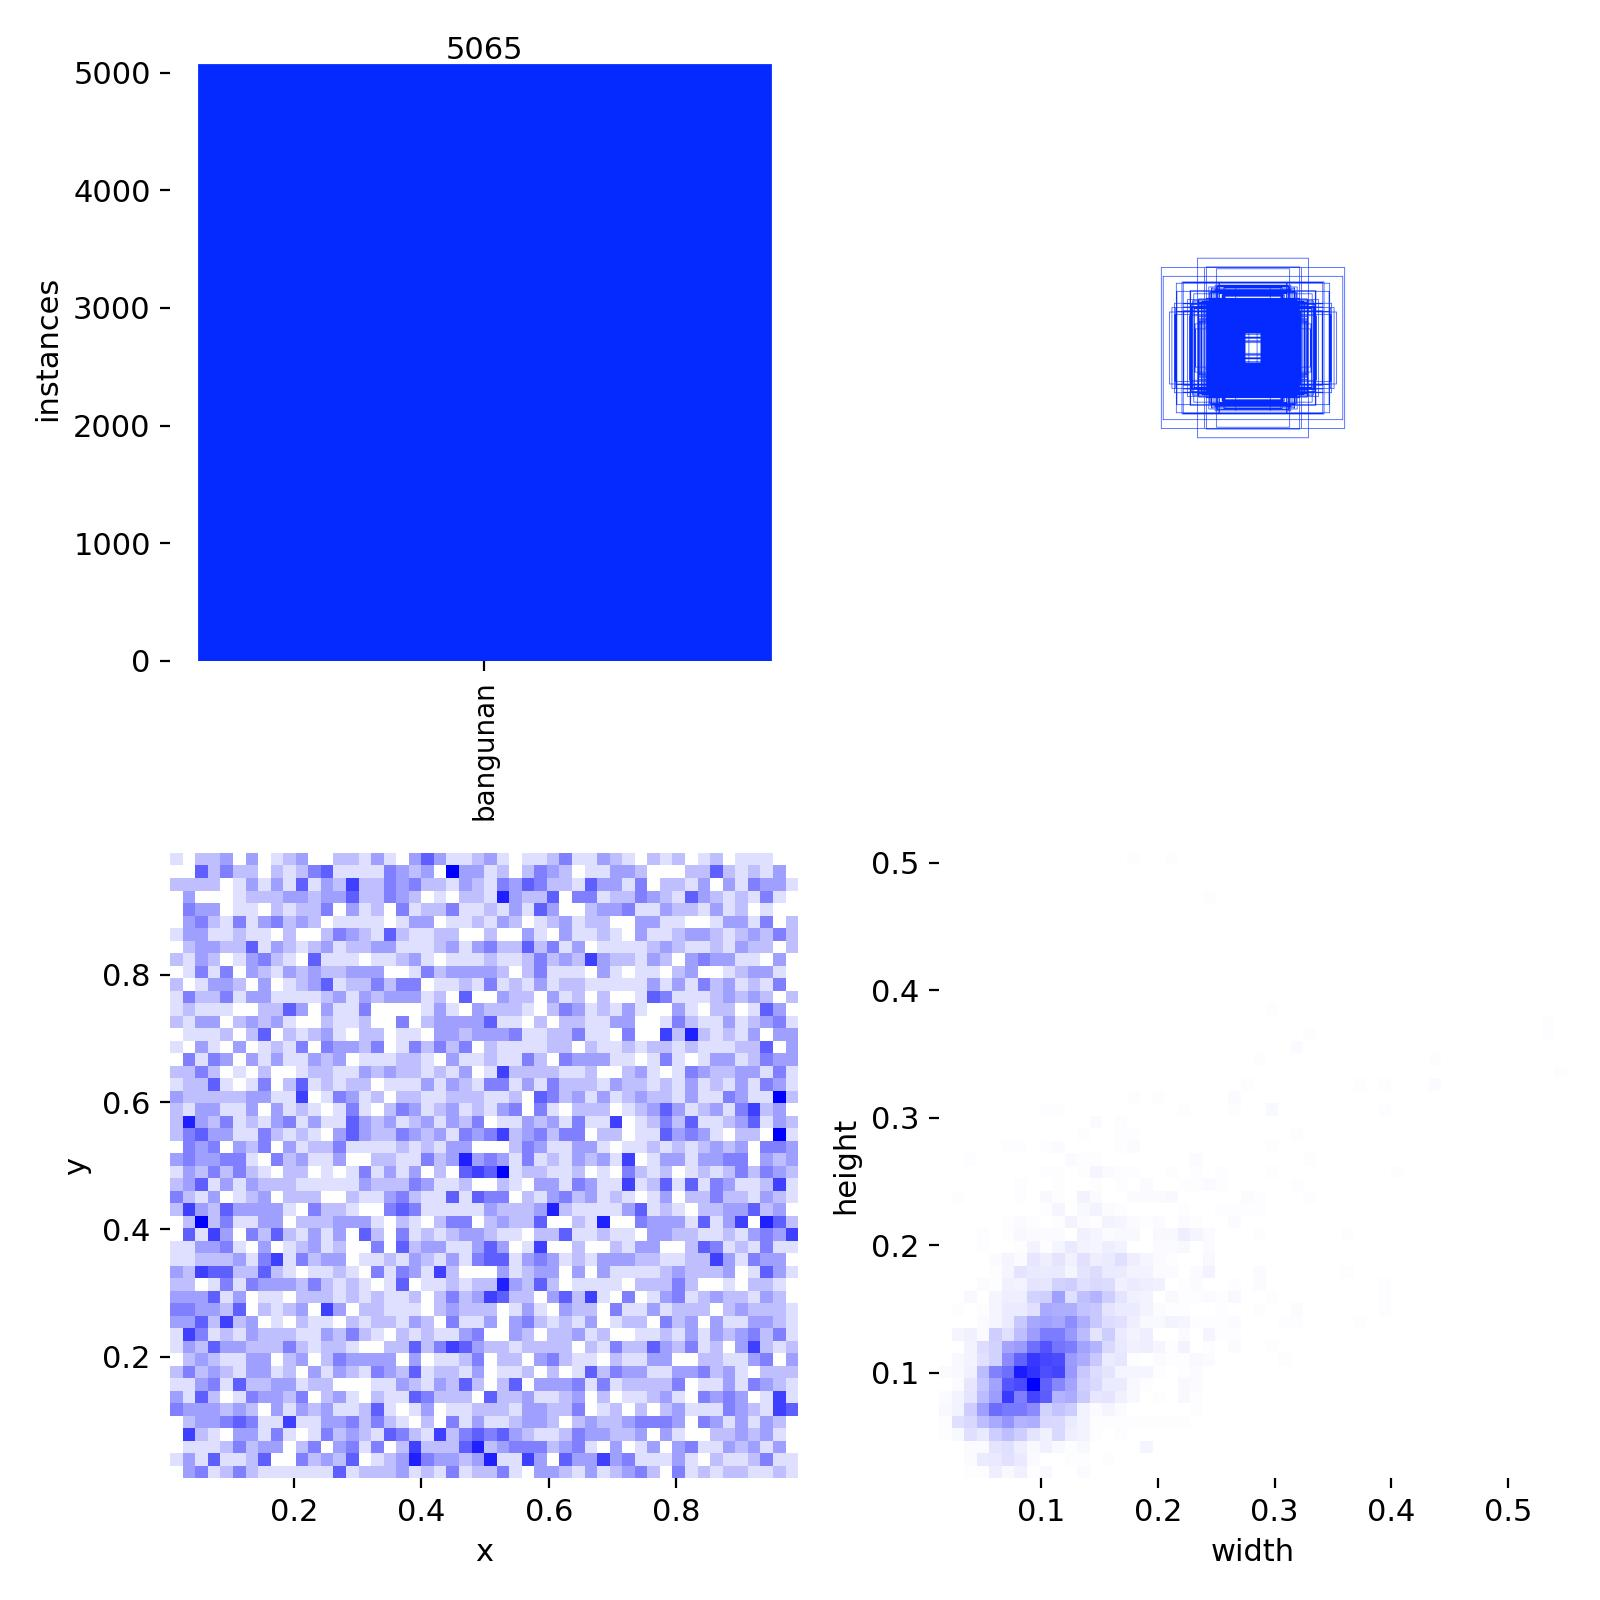

In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('=' * 60)
print('     EXPLORATORY DATA ANALYSIS — DATASET')
print('=' * 60)

train_img_dir   = f'{dataset.location}/train/images'
train_lbl_dir   = f'{dataset.location}/train/labels'
val_img_dir     = f'{dataset.location}/valid/images'
val_lbl_dir     = f'{dataset.location}/valid/labels'
test_img_dir    = f'{dataset.location}/test/images'
test_lbl_dir    = f'{dataset.location}/test/labels'

# ── Hitung statistik per split
def count_split(img_dir, lbl_dir):
    imgs   = [f for f in os.listdir(img_dir) if f.endswith(('.jpg','.png'))] if os.path.exists(img_dir) else []
    total_bbox = 0
    empty_tiles = 0
    bbox_per_tile = []
    for img in imgs:
        lbl = os.path.join(lbl_dir, img.rsplit('.',1)[0] + '.txt')
        if os.path.exists(lbl):
            with open(lbl) as f:
                lines = [l for l in f.readlines() if l.strip()]
            n = len(lines)
        else:
            n = 0
        total_bbox += n
        bbox_per_tile.append(n)
        if n == 0:
            empty_tiles += 1
    return len(imgs), total_bbox, empty_tiles, bbox_per_tile

n_train, bbox_train, empty_train, bpt_train = count_split(train_img_dir, train_lbl_dir)
n_val,   bbox_val,   empty_val,   bpt_val   = count_split(val_img_dir,   val_lbl_dir)
n_test,  bbox_test,  empty_test,  bpt_test  = count_split(test_img_dir,  test_lbl_dir)
n_total  = n_train + n_val + n_test
bbox_all = bbox_train + bbox_val + bbox_test

print(f'\n── Tabel Statistik Dataset ──')
print(f'{"Split":<10} {"Gambar":>8} {"BBox":>8} {"Tile Kosong":>12} {"Rata BBox/Tile":>15}')
print(f'{"-"*55}')
print(f'{"Train":<10} {n_train:>8} {bbox_train:>8} {empty_train:>12} {np.mean(bpt_train):>15.1f}')
print(f'{"Valid":<10} {n_val:>8} {bbox_val:>8} {empty_val:>12} {np.mean(bpt_val):>15.1f}')
print(f'{"Test":<10} {n_test:>8} {bbox_test:>8} {empty_test:>12} {np.mean(bpt_test) if bpt_test else 0:>15.1f}')
print(f'{"-"*55}')
print(f'{"Total":<10} {n_total:>8} {bbox_all:>8} {empty_train+empty_val+empty_test:>12} {np.mean(bpt_train+bpt_val):>15.1f}')

# ── Analisis ukuran bbox di training set
bbox_w_list, bbox_h_list, bbox_area_list = [], [], []
for lbl_file in glob.glob(f'{train_lbl_dir}/*.txt'):
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                w, h = float(parts[3]), float(parts[4])
                bbox_w_list.append(w * 512)    # pixel
                bbox_h_list.append(h * 512)
                bbox_area_list.append(w * h * 512 * 512)

bbox_w_arr    = np.array(bbox_w_list)
bbox_h_arr    = np.array(bbox_h_list)
bbox_area_arr = np.array(bbox_area_list)

print(f'\n── Statistik Ukuran Bounding Box (training set, dalam pixel 512x512) ──')
print(f'  Total bbox     : {len(bbox_w_arr)}')
print(f'  Lebar rata-rata: {bbox_w_arr.mean():.1f} px (min={bbox_w_arr.min():.0f}, max={bbox_w_arr.max():.0f})')
print(f'  Tinggi rata-rata:{bbox_h_arr.mean():.1f} px (min={bbox_h_arr.min():.0f}, max={bbox_h_arr.max():.0f})')
print(f'  Area rata-rata : {bbox_area_arr.mean():.0f} px² ({(bbox_area_arr.mean()/(512*512)*100):.1f}% dari tile)')

# ── Visualisasi EDA 6 panel
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Panel 1: Bar chart split
splits  = ['Train', 'Valid', 'Test']
n_imgs  = [n_train, n_val, n_test]
n_bboxs = [bbox_train, bbox_val, bbox_test]
x = np.arange(len(splits))
w = 0.35
bars1 = axes[0,0].bar(x - w/2, n_imgs,  w, label='Gambar', color='steelblue')
bars2 = axes[0,0].bar(x + w/2, n_bboxs, w, label='BBox',   color='tomato')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(splits)
axes[0,0].set_title('Distribusi Dataset per Split', fontsize=11)
axes[0,0].set_ylabel('Jumlah')
axes[0,0].legend()
for bar in bars1:
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                   str(int(bar.get_height())), ha='center', fontsize=9)
for bar in bars2:
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                   str(int(bar.get_height())), ha='center', fontsize=9)

# Panel 2: Histogram bbox per tile
all_bpt = bpt_train + bpt_val
axes[0,1].hist(all_bpt, bins=20, color='steelblue', edgecolor='white')
axes[0,1].axvline(np.mean(all_bpt), color='red', linestyle='--', label=f'Mean: {np.mean(all_bpt):.1f}')
axes[0,1].axvline(np.median(all_bpt), color='orange', linestyle='--', label=f'Median: {np.median(all_bpt):.1f}')
axes[0,1].set_title('Distribusi Jumlah BBox per Tile', fontsize=11)
axes[0,1].set_xlabel('Jumlah BBox per Tile')
axes[0,1].set_ylabel('Frekuensi')
axes[0,1].legend(fontsize=9)

# Panel 3: Pie chart tile kosong vs berisi
total_counted = n_train + n_val
total_empty   = empty_train + empty_val
axes[0,2].pie(
    [total_counted - total_empty, total_empty],
    labels=[f'Berisi\n({total_counted-total_empty})', f'Kosong\n({total_empty})'],
    colors=['#4CAF50','#F44336'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0,2].set_title('Proporsi Tile Berisi vs Kosong', fontsize=11)

# Panel 4: Distribusi lebar bbox
axes[1,0].hist(bbox_w_arr, bins=30, color='royalblue', edgecolor='white')
axes[1,0].axvline(bbox_w_arr.mean(), color='red', linestyle='--', label=f'Mean: {bbox_w_arr.mean():.0f}px')
axes[1,0].set_title('Distribusi Lebar Bounding Box', fontsize=11)
axes[1,0].set_xlabel('Lebar (pixel)')
axes[1,0].set_ylabel('Frekuensi')
axes[1,0].legend(fontsize=9)

# Panel 5: Distribusi tinggi bbox
axes[1,1].hist(bbox_h_arr, bins=30, color='darkorange', edgecolor='white')
axes[1,1].axvline(bbox_h_arr.mean(), color='red', linestyle='--', label=f'Mean: {bbox_h_arr.mean():.0f}px')
axes[1,1].set_title('Distribusi Tinggi Bounding Box', fontsize=11)
axes[1,1].set_xlabel('Tinggi (pixel)')
axes[1,1].set_ylabel('Frekuensi')
axes[1,1].legend(fontsize=9)

# Panel 6: Scatter lebar vs tinggi bbox
sample_idx = np.random.choice(len(bbox_w_arr), min(1000, len(bbox_w_arr)), replace=False)
sc = axes[1,2].scatter(bbox_w_arr[sample_idx], bbox_h_arr[sample_idx], alpha=0.4, s=8, c=bbox_area_arr[sample_idx], cmap='YlOrRd')
plt.colorbar(sc, ax=axes[1,2], label='Area (px²)')
axes[1,2].set_title('Sebaran Dimensi BBox (sampel 1000)', fontsize=11)
axes[1,2].set_xlabel('Lebar (pixel)')
axes[1,2].set_ylabel('Tinggi (pixel)')
axes[1,2].plot([0, 512], [0, 512], 'k--', alpha=0.3, label='Rasio 1:1')
axes[1,2].legend(fontsize=8)

plt.suptitle('Exploratory Data Analysis — Dataset Deteksi Bangunan Pangalengan', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA dataset tersimpan: eda_dataset.png')

# ── Tampilkan labels.jpg dari YOLO (distribusi posisi label di tile)
labels_img = f'{TRAINING_RESULT_DIR}/labels.jpg'
if os.path.exists(labels_img):
    from IPython.display import Image as IPImage, display
    print('\nDistribusi posisi & ukuran label di seluruh tile (dari YOLO):')
    display(IPImage(labels_img, width=700))


---
# BAGIAN 3 — TRAINING

## CELL 3.0 — Update Konfigurasi Training untuk Dataset Baru

In [ ]:
# Update versi Roboflow ke dataset 2184 tile
ROBOFLOW_VERSION = 3   # ← ganti ke nomor versi terbaru di Roboflow kamu

# Nama run baru agar tidak timpa hasil sebelumnya
TRAIN_NAME_NEW   = 'bangunan_pangalengan_v2'   # v2 = pakai 2184 tile

print('=== KONFIGURASI TRAINING BARU ===')
print(f'Dataset version  : {ROBOFLOW_VERSION} (2184 tile + augmentasi)')
print(f'Nama run         : {TRAIN_NAME_NEW}')
print(f'Epochs           : 100 (dinaikkan karena dataset lebih besar)')
print(f'Batch size       : 16')
print(f'Imgsz            : 512')
print(f'Patience         : 15')
print()
print('Jalankan Cell 2.1 lagi setelah ini untuk download dataset baru,')
print('lalu lanjut ke Cell 3.1 dengan parameter di atas.')


=== KONFIGURASI TRAINING BARU ===
Dataset version  : 3 (2184 tile + augmentasi)
Nama run         : bangunan_pangalengan_v2
Epochs           : 100 (dinaikkan karena dataset lebih besar)
Batch size       : 16
Imgsz            : 512
Patience         : 15

Jalankan Cell 2.1 lagi setelah ini untuk download dataset baru,
lalu lanjut ke Cell 3.1 dengan parameter di atas.


## 3.1 — Training YOLOv8
> Estimasi: 20–40 menit di T4 GPU. Jangan tutup tab.

In [ ]:
from ultralytics import YOLO

TRAIN_NAME = 'bangunan_pangalengan_v1'

model = YOLO('yolov8n.pt')
print(f"🚀 Training YOLOv8n | {TRAIN_NAME}\n")

results = model.train(
    data        = f'{dataset.location}/data.yaml',
    epochs      = 100,
    imgsz       = 512,
    batch       = 16,
    patience    = 15,
    name        = TRAIN_NAME,
    project     = '/content/runs/detect',
    exist_ok    = True,
    plots       = True,
    verbose     = True,
    save        = True,
    save_period = 10,
    val         = True,
)

TRAIN_DIR   = f'/content/runs/detect/{TRAIN_NAME}'
BEST_PT_SRC = f'{TRAIN_DIR}/weights/best.pt'
LAST_PT_SRC = f'{TRAIN_DIR}/weights/last.pt'

print(f"\n✅ Training selesai!")
print(f"   best.pt : {'✅' if os.path.exists(BEST_PT_SRC) else '❌'}")
print(f"   last.pt : {'✅' if os.path.exists(LAST_PT_SRC) else '❌'}")
print(f"\nFile hasil:")
for f in sorted(os.listdir(TRAIN_DIR)):
    if not os.path.isdir(f'{TRAIN_DIR}/{f}'):
        sz = os.path.getsize(f'{TRAIN_DIR}/{f}')/1024
        print(f"  📄 {f} ({sz:.0f} KB)")


🚀 Training YOLOv8n | bangunan_pangalengan_v1

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/SIG_Deteksi_Bangunan/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=banguna

---
# BAGIAN 4 — EVALUASI LENGKAP

## 4.1 — Metrik Evaluasi (Validation Set)

In [ ]:
from ultralytics import YOLO
import numpy as np

print("Menjalankan evaluasi di validation set...")
best_model = YOLO(BEST_PT_SRC)

metrics = best_model.val(
    data    = f'{dataset.location}/data.yaml',
    imgsz   = 512,
    verbose = False
)

map50    = float(metrics.box.map50)
map5095  = float(metrics.box.map)
prec     = float(metrics.box.p.mean())
rec      = float(metrics.box.r.mean())
f1       = 2*(prec*rec)/(prec+rec+1e-9)

def grade(val, t_good=0.7, t_ok=0.5):
    return '✅ Bagus' if val>=t_good else ('🟡 Cukup' if val>=t_ok else '🔴 Perlu perbaikan')

print("\n" + "="*52)
print("          HASIL EVALUASI MODEL")
print("="*52)
print(f"  mAP@50        : {map50:.4f}   {grade(map50)}")
print(f"  mAP@50-95     : {map5095:.4f}")
print(f"  Precision     : {prec:.4f}   {grade(prec,0.7,0.6)}")
print(f"  Recall        : {rec:.4f}   {grade(rec,0.7,0.6)}")
print(f"  F1-Score      : {f1:.4f}   {grade(f1,0.7,0.5)}")
print("="*52)

if map50 >= 0.7:
    print("\n  ✅ Model siap dipakai untuk inference")
elif map50 >= 0.5:
    print("\n  🟡 Model cukup layak, tambah data jika ada waktu")
else:
    print("\n  🔴 Tambah data/epoch sebelum inference")

# Simpan metrik ke dict untuk dipakai cell berikutnya
eval_metrics = {
    'mAP50': map50, 'mAP50_95': map5095,
    'Precision': prec, 'Recall': rec, 'F1': f1
}


Menjalankan evaluasi di validation set...
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.7±0.3 ms, read: 17.6±3.2 MB/s, size: 32.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/SIG_Deteksi_Bangunan/dataset/valid/labels.cache... 32 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32/32 11.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.0it/s 1.0s
                   all         32        467      0.724      0.749      0.778      0.477
Speed: 4.1ms preprocess, 4.4ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/runs/detect/val-2

          HASIL EVALUASI MODEL
  mAP@50        : 0.778

## 4.2 — Grafik Training (Loss & Metrik per Epoch)

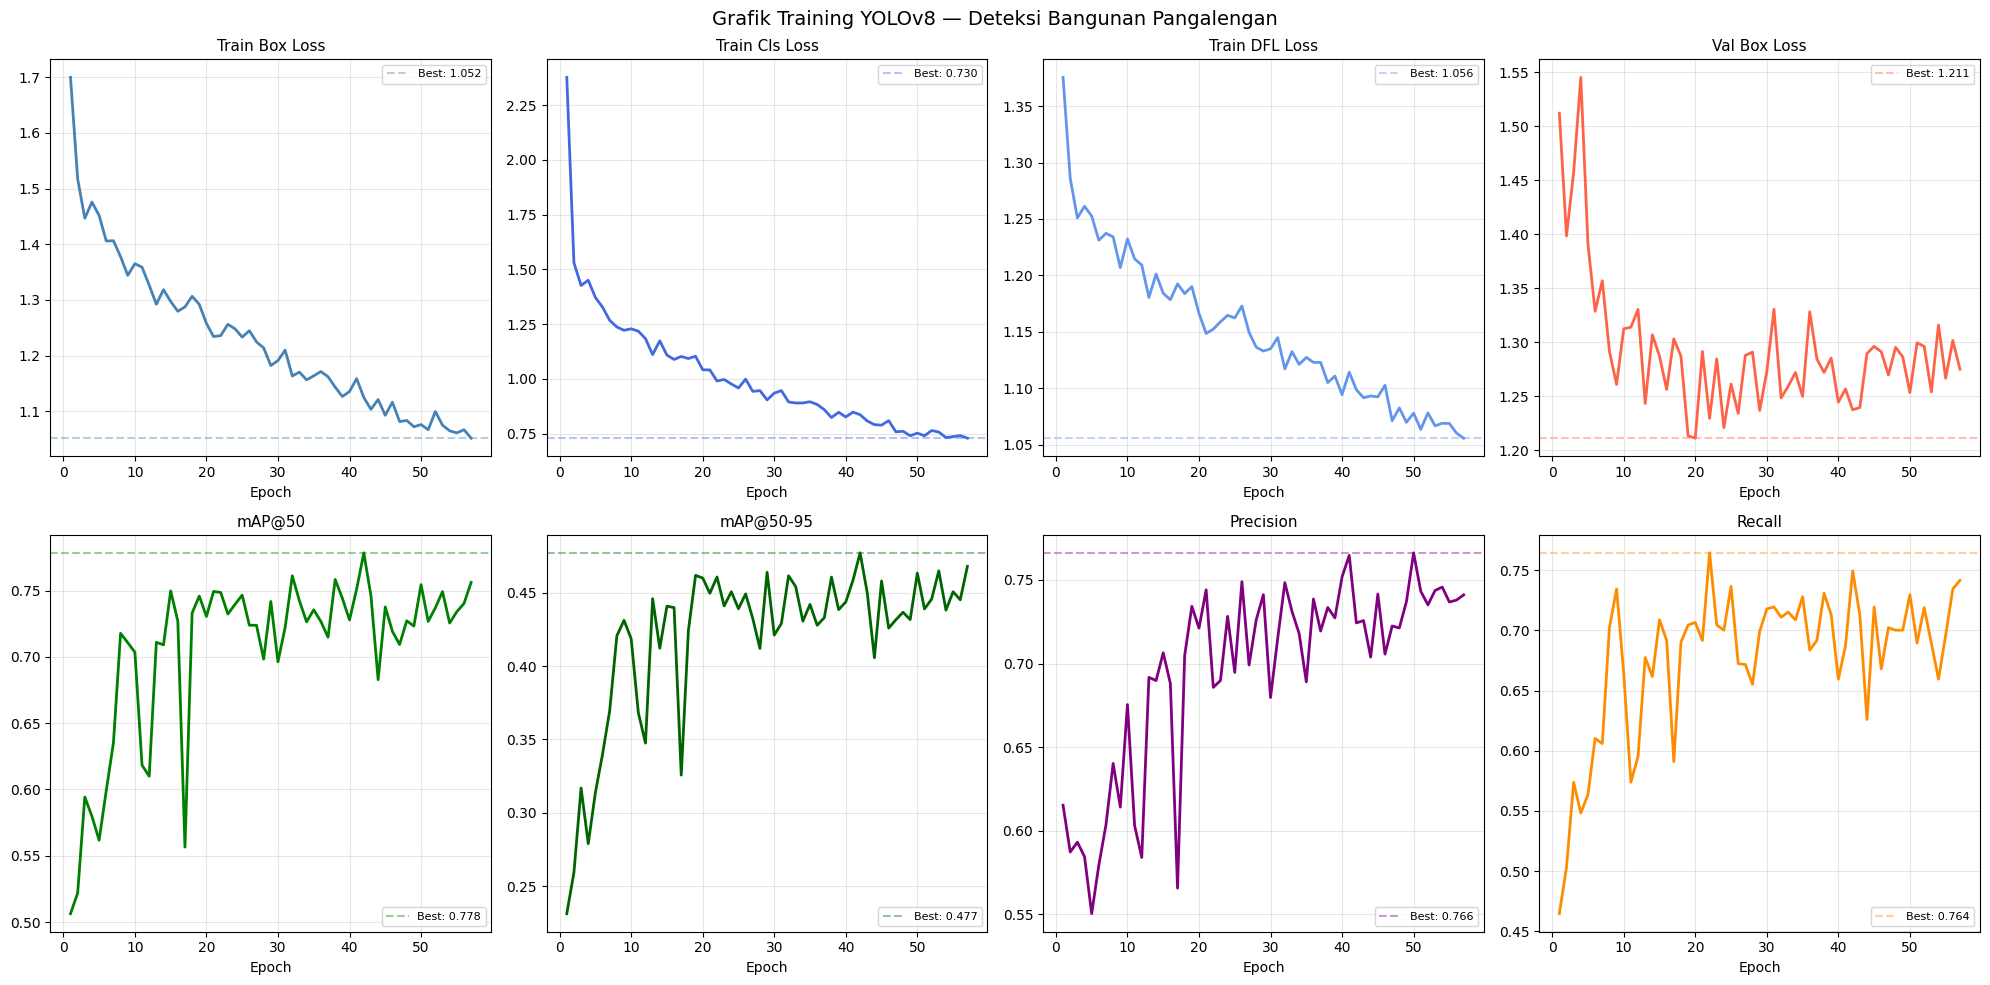

Epoch terbaik  : 42
  train_box_loss : 1.1248
  train_cls_loss : 0.8368
  train_dfl_loss : 1.0988
  precision      : 0.7243
  recall         : 0.7495
  map50          : 0.7785
  map5095        : 0.4772
  val_box_loss   : 1.2374
  val_cls_loss   : 1.0071

✅ Grafik training tersimpan


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = f'{TRAIN_DIR}/results.csv'

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    # Deteksi nama kolom otomatis
    col_map = {}
    for c in df.columns:
        cl = c.lower()
        if 'box_loss' in cl and 'train' in cl:   col_map['train_box_loss'] = c
        if 'cls_loss' in cl and 'train' in cl:    col_map['train_cls_loss'] = c
        if 'dfl_loss' in cl and 'train' in cl:    col_map['train_dfl_loss'] = c
        if 'box_loss' in cl and 'val' in cl:      col_map['val_box_loss'] = c
        if 'cls_loss' in cl and 'val' in cl:      col_map['val_cls_loss'] = c
        if 'map50' in cl and '95' not in cl:      col_map['map50'] = c
        if 'map50-95' in cl or 'map(b)' in cl:   col_map['map5095'] = c
        if 'precision' in cl:                      col_map['precision'] = c
        if 'recall' in cl:                         col_map['recall'] = c

    epoch = df['epoch'] if 'epoch' in df.columns else df.index

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    plot_items = [
        ('train_box_loss', 'Train Box Loss',  'steelblue'),
        ('train_cls_loss', 'Train Cls Loss',  'royalblue'),
        ('train_dfl_loss', 'Train DFL Loss',  'cornflowerblue'),
        ('val_box_loss',   'Val Box Loss',    'tomato'),
        ('map50',          'mAP@50',          'green'),
        ('map5095',        'mAP@50-95',       'darkgreen'),
        ('precision',      'Precision',       'purple'),
        ('recall',         'Recall',          'darkorange'),
    ]

    for idx, (key, title, color) in enumerate(plot_items):
        if key in col_map and col_map[key] in df.columns:
            axes[idx].plot(epoch, df[col_map[key]], color=color, linewidth=2)
            axes[idx].set_title(title, fontsize=11)
            axes[idx].set_xlabel('Epoch')
            axes[idx].grid(True, alpha=0.3)
            # Annotate best value
            best_val = df[col_map[key]].max() if 'map' in key or key in ['precision','recall'] else df[col_map[key]].min()
            axes[idx].axhline(best_val, color=color, linestyle='--', alpha=0.4,
                             label=f'Best: {best_val:.3f}')
            axes[idx].legend(fontsize=8)
        else:
            axes[idx].set_title(f'{title} (tidak ada)', fontsize=9)
            axes[idx].axis('off')

    plt.suptitle('Grafik Training YOLOv8 — Deteksi Bangunan Pangalengan', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/grafik_training_lengkap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Epoch terbaik
    if 'map50' in col_map:
        best_idx = df[col_map['map50']].idxmax()
        print(f"Epoch terbaik  : {int(df.loc[best_idx,'epoch'])}")
        for key, c in col_map.items():
            print(f"  {key:<15}: {df.loc[best_idx,c]:.4f}")
    print(f"\n✅ Grafik training tersimpan")
else:
    print("⚠️  results.csv tidak ditemukan")


## 4.3 — Semua Kurva Evaluasi

Ditemukan 6 file kurva & matrix:
  📈 BoxF1_curve.png
  📈 BoxPR_curve.png
  📈 BoxP_curve.png
  📈 BoxR_curve.png
  📈 confusion_matrix.png
  📈 confusion_matrix_normalized.png


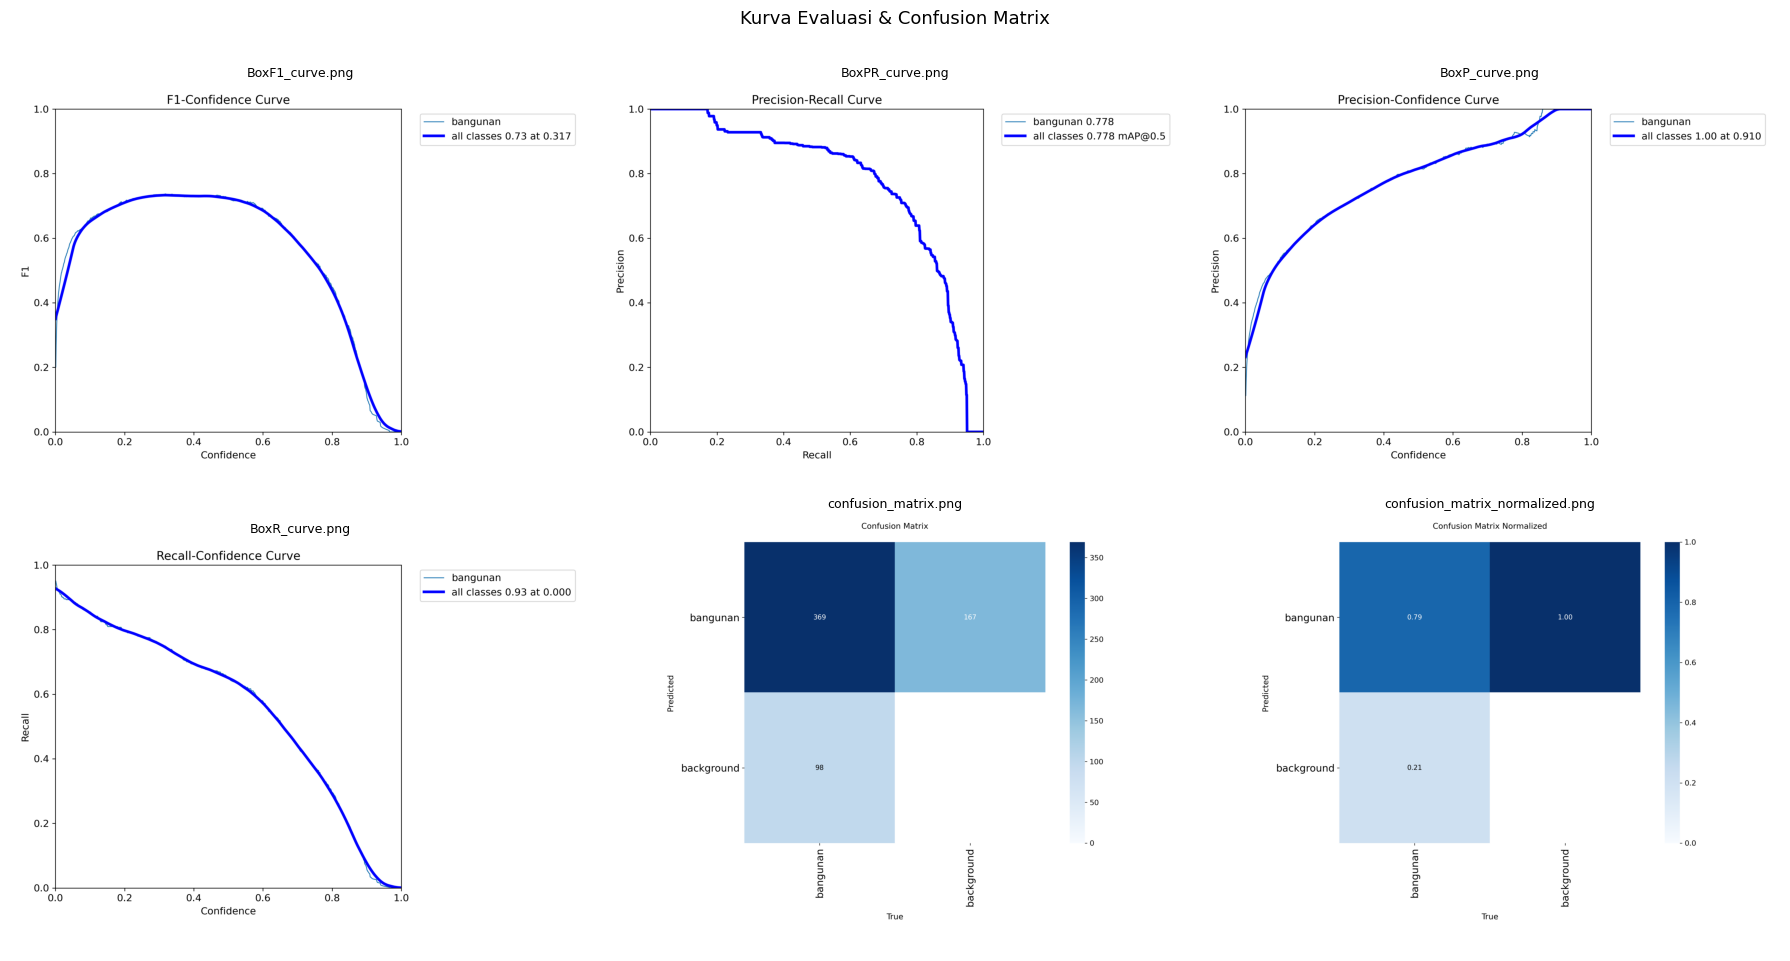

✅ Semua kurva divisualisasikan


In [ ]:
from IPython.display import Image as IPImage, display
import glob, math

# Kumpulkan semua file gambar kurva dari hasil training
curve_files = sorted(glob.glob(f'{TRAIN_DIR}/*curve*.png') +
                     glob.glob(f'{TRAIN_DIR}/*Curve*.png'))
matrix_files= sorted(glob.glob(f'{TRAIN_DIR}/confusion*.png'))
all_curves  = curve_files + matrix_files

print(f"Ditemukan {len(all_curves)} file kurva & matrix:")
for f in all_curves:
    print(f"  📈 {os.path.basename(f)}")

if all_curves:
    ncols = 3
    nrows = math.ceil(len(all_curves) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5*nrows))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols==1 else axes.flatten()

    for idx, fpath in enumerate(all_curves):
        img = plt.imread(fpath)
        axes[idx].imshow(img)
        axes[idx].set_title(os.path.basename(fpath), fontsize=9)
        axes[idx].axis('off')

    for idx in range(len(all_curves), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Kurva Evaluasi & Confusion Matrix', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/semua_kurva_evaluasi.png', dpi=130, bbox_inches='tight')
    plt.show()
    print("✅ Semua kurva divisualisasikan")
else:
    print("⚠️  Tidak ada file kurva ditemukan")
    print("   Jalankan ulang training dengan plots=True")


## 4.4 — Visualisasi Prediksi di Validation Set

Batch prediksi ditemukan: 1


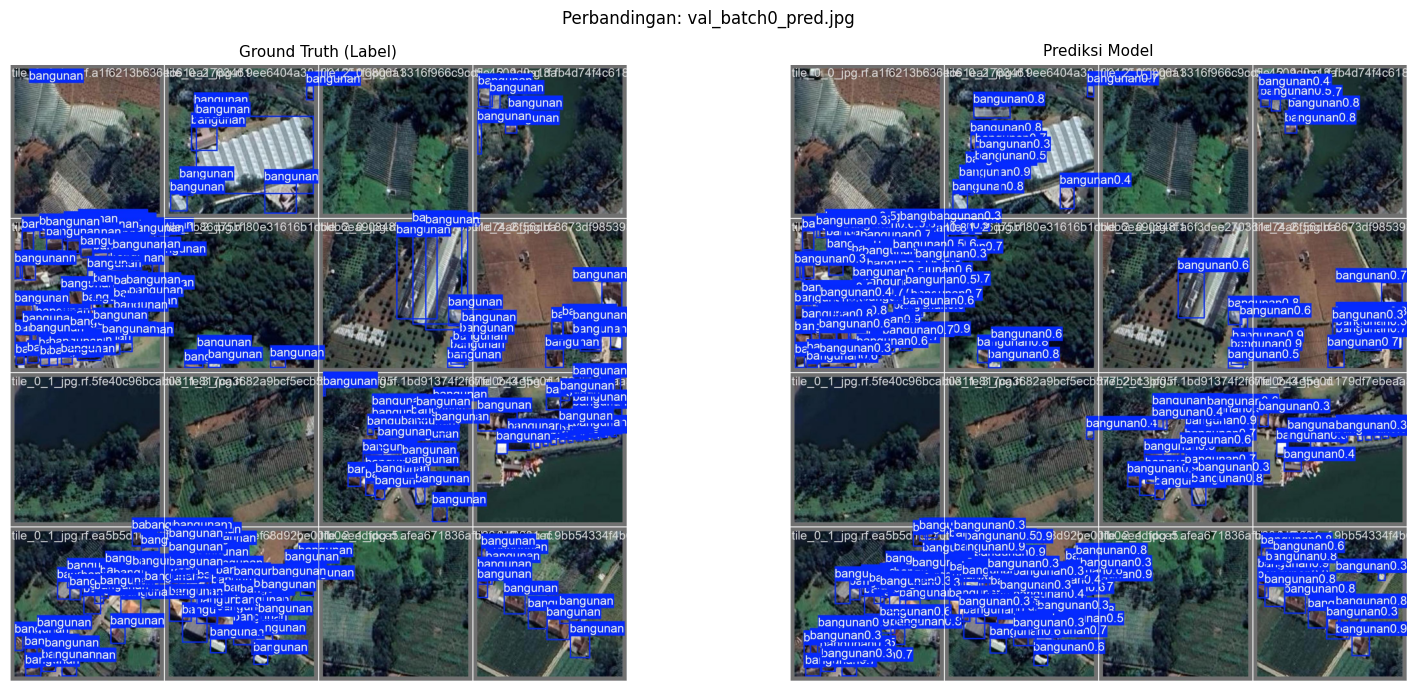

✅ Visualisasi prediksi selesai


In [ ]:
from IPython.display import Image as IPImage, display
import glob

pred_imgs   = sorted(glob.glob(f'{TRAIN_DIR}/val_batch*_pred.jpg'))
label_imgs  = sorted(glob.glob(f'{TRAIN_DIR}/val_batch*_labels.jpg'))

print(f"Batch prediksi ditemukan: {len(pred_imgs)}")

for pred_path in pred_imgs[:3]:
    base    = os.path.basename(pred_path)
    lbl_path= pred_path.replace('_pred.jpg','_labels.jpg')

    if os.path.exists(lbl_path):
        # Tampilkan label vs prediksi berdampingan
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        axes[0].imshow(plt.imread(lbl_path))
        axes[0].set_title('Ground Truth (Label)', fontsize=11)
        axes[0].axis('off')
        axes[1].imshow(plt.imread(pred_path))
        axes[1].set_title('Prediksi Model', fontsize=11)
        axes[1].axis('off')
        plt.suptitle(f'Perbandingan: {base}', fontsize=12)
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/perbandingan_{base}', dpi=120, bbox_inches='tight')
        plt.show()
    else:
        display(IPImage(pred_path, width=700))

print("✅ Visualisasi prediksi selesai")


## 4.5 — Ringkasan Evaluasi (Report Card)

Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.


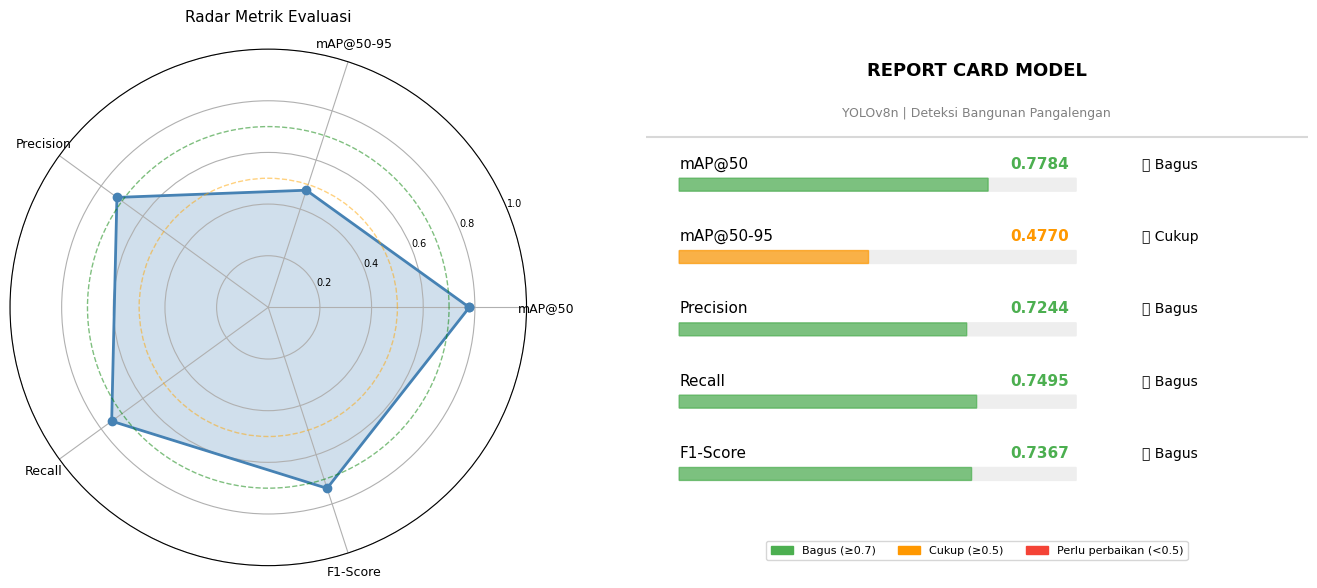

✅ Report card evaluasi tersimpan


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig = plt.figure(figsize=(14, 6))

# ── Radar chart metrik
ax1 = fig.add_subplot(121, projection='polar')
categories = ['mAP@50','mAP@50-95','Precision','Recall','F1-Score']
values     = [eval_metrics['mAP50'], eval_metrics['mAP50_95'],
              eval_metrics['Precision'], eval_metrics['Recall'],
              eval_metrics['F1']]
values_plot = values + [values[0]]
N    = len(categories)
angles = [n/float(N)*2*np.pi for n in range(N)]
angles += angles[:1]

ax1.plot(angles, values_plot, 'o-', linewidth=2, color='steelblue')
ax1.fill(angles, values_plot, alpha=0.25, color='steelblue')
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories, size=9)
ax1.set_ylim(0, 1)
ax1.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax1.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], size=7)
ax1.set_title('Radar Metrik Evaluasi', pad=20, fontsize=11)
ax1.axhline(y=0.5, color='orange', linestyle='--', alpha=0.5, linewidth=1)
ax1.axhline(y=0.7, color='green',  linestyle='--', alpha=0.5, linewidth=1)

# ── Report card teks
ax2 = fig.add_subplot(122)
ax2.axis('off')

def grade_color(v, t1=0.7, t2=0.5):
    return ('#4CAF50' if v>=t1 else '#FF9800' if v>=t2 else '#F44336')

report_data = [
    ('mAP@50',    eval_metrics['mAP50'],    0.7, 0.5),
    ('mAP@50-95', eval_metrics['mAP50_95'], 0.5, 0.3),
    ('Precision', eval_metrics['Precision'],0.7, 0.6),
    ('Recall',    eval_metrics['Recall'],   0.7, 0.6),
    ('F1-Score',  eval_metrics['F1'],       0.7, 0.5),
]

y = 0.95
ax2.text(0.5, y, 'REPORT CARD MODEL', ha='center', fontsize=13,
         fontweight='bold', transform=ax2.transAxes)
y -= 0.08
ax2.text(0.5, y, 'YOLOv8n | Deteksi Bangunan Pangalengan',
         ha='center', fontsize=9, color='gray', transform=ax2.transAxes)
y -= 0.04
ax2.axhline(y=y*ax2.get_ylim()[1] if ax2.get_ylim()[1]!=1 else y,
            color='gray', alpha=0.3)
y -= 0.06

for name, val, t1, t2 in report_data:
    color = grade_color(val, t1, t2)
    grade = '✅ Bagus' if val>=t1 else ('🟡 Cukup' if val>=t2 else '🔴 Rendah')
    ax2.text(0.05, y, name, fontsize=11, transform=ax2.transAxes)
    ax2.text(0.55, y, f'{val:.4f}', fontsize=11,
             fontweight='bold', color=color, transform=ax2.transAxes)
    ax2.text(0.75, y, grade, fontsize=10, transform=ax2.transAxes)

    # Progress bar
    bar_w = val * 0.6
    ax2.add_patch(mpatches.FancyBboxPatch(
        (0.05, y-0.045), 0.6, 0.025,
        boxstyle='round,pad=0', color='#eee', transform=ax2.transAxes, clip_on=False))
    ax2.add_patch(mpatches.FancyBboxPatch(
        (0.05, y-0.045), bar_w, 0.025,
        boxstyle='round,pad=0', color=color, alpha=0.7,
        transform=ax2.transAxes, clip_on=False))
    y -= 0.14

legend_els = [
    mpatches.Patch(color='#4CAF50', label='Bagus (≥0.7)'),
    mpatches.Patch(color='#FF9800', label='Cukup (≥0.5)'),
    mpatches.Patch(color='#F44336', label='Perlu perbaikan (<0.5)'),
]
ax2.legend(handles=legend_els, loc='lower center',
           bbox_to_anchor=(0.5, 0.0), fontsize=8, ncol=3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/report_card_evaluasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Report card evaluasi tersimpan")


## CELL 4.6 — Tabel Perbandingan & Diskusi Model (Untuk Paper)

     TABEL PERBANDINGAN & DISKUSI MODEL

Tabel Perbandingan Konfigurasi Model:
            Konfigurasi   Dataset                       Augmentasi Epochs mAP@50 mAP@50-95 Precision Recall F1-Score Inferensi/img
 YOLOv8n (216 tile, v1)  216 tile                 Flip, Brightness     42  0.776      0.49     0.748  0.732     0.74         1.3ms
YOLOv8n (2184 tile, v2) 2184 tile Flip, Rotation, Blur, Brightness      -      -         -         -      -        -             -


Catatan untuk mengisi tabel setelah training v2 selesai:
  eval_metrics dari Cell 4.1 → isi baris kedua tabel di atas
  Simpan tabel ini sebagai referensi untuk Bab 4 paper



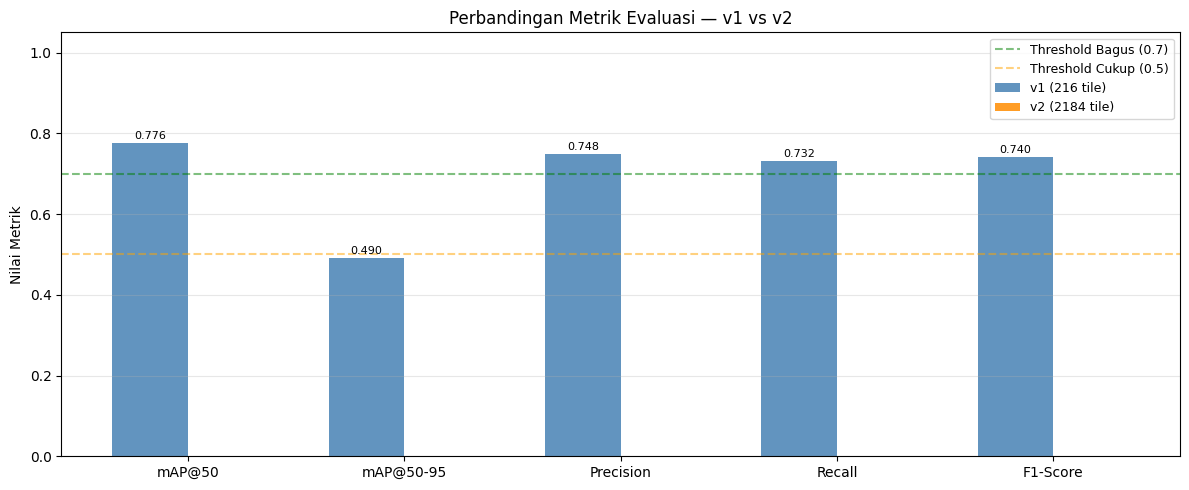

Grafik perbandingan tersimpan: perbandingan_model.png
(Update nilai v2 setelah training dengan 2184 tile selesai)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print('=' * 65)
print('     TABEL PERBANDINGAN & DISKUSI MODEL')
print('=' * 65)

# Data dari training run yang sudah selesai
# Isi manual setelah training v2 selesai untuk baris kedua
comparison_data = {
    'Konfigurasi'   : ['YOLOv8n (216 tile, v1)', 'YOLOv8n (2184 tile, v2)'],
    'Dataset'       : ['216 tile', '2184 tile'],
    'Augmentasi'    : ['Flip, Brightness', 'Flip, Rotation, Blur, Brightness'],
    'Epochs'        : [42, '-'],
    'mAP@50'        : [0.776, '-'],
    'mAP@50-95'     : [0.490, '-'],
    'Precision'     : [0.748, '-'],
    'Recall'        : [0.732, '-'],
    'F1-Score'      : [round(2*0.748*0.732/(0.748+0.732), 3), '-'],
    'Inferensi/img' : ['1.3ms', '-'],
}

df_compare = pd.DataFrame(comparison_data)
print('\nTabel Perbandingan Konfigurasi Model:')
print(df_compare.to_string(index=False))

print('\n\nCatatan untuk mengisi tabel setelah training v2 selesai:')
print('  eval_metrics dari Cell 4.1 → isi baris kedua tabel di atas')
print('  Simpan tabel ini sebagai referensi untuk Bab 4 paper\n')

# Visualisasi bar chart perbandingan (bisa diupdate setelah v2 selesai)
fig, ax = plt.subplots(figsize=(12, 5))

metrics_name  = ['mAP@50', 'mAP@50-95', 'Precision', 'Recall', 'F1-Score']
values_v1     = [0.776, 0.490, 0.748, 0.732, round(2*0.748*0.732/(0.748+0.732),3)]
values_v2     = [0, 0, 0, 0, 0]  # ← update setelah training v2

x  = np.arange(len(metrics_name))
w  = 0.35
b1 = ax.bar(x - w/2, values_v1, w, label='v1 (216 tile)', color='steelblue',  alpha=0.85)
b2 = ax.bar(x + w/2, values_v2, w, label='v2 (2184 tile)',color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_name)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Nilai Metrik')
ax.set_title('Perbandingan Metrik Evaluasi — v1 vs v2', fontsize=12)
ax.axhline(0.7, color='green',  linestyle='--', alpha=0.5, label='Threshold Bagus (0.7)')
ax.axhline(0.5, color='orange', linestyle='--', alpha=0.5, label='Threshold Cukup (0.5)')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

for bar in b1:
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik perbandingan tersimpan: perbandingan_model.png')
print('(Update nilai v2 setelah training dengan 2184 tile selesai)')


## CELL 4.7 — Error Analysis (False Positive & False Negative)

Menjalankan error analysis di validation set...

=== HASIL ERROR ANALYSIS (val set) ===
  Total TP : 346
  Total FP : 86  (bukan bangunan tapi dideteksi)
  Total FN : 121  (bangunan asli tapi terlewat)
  Precision: 0.801
  Recall   : 0.741


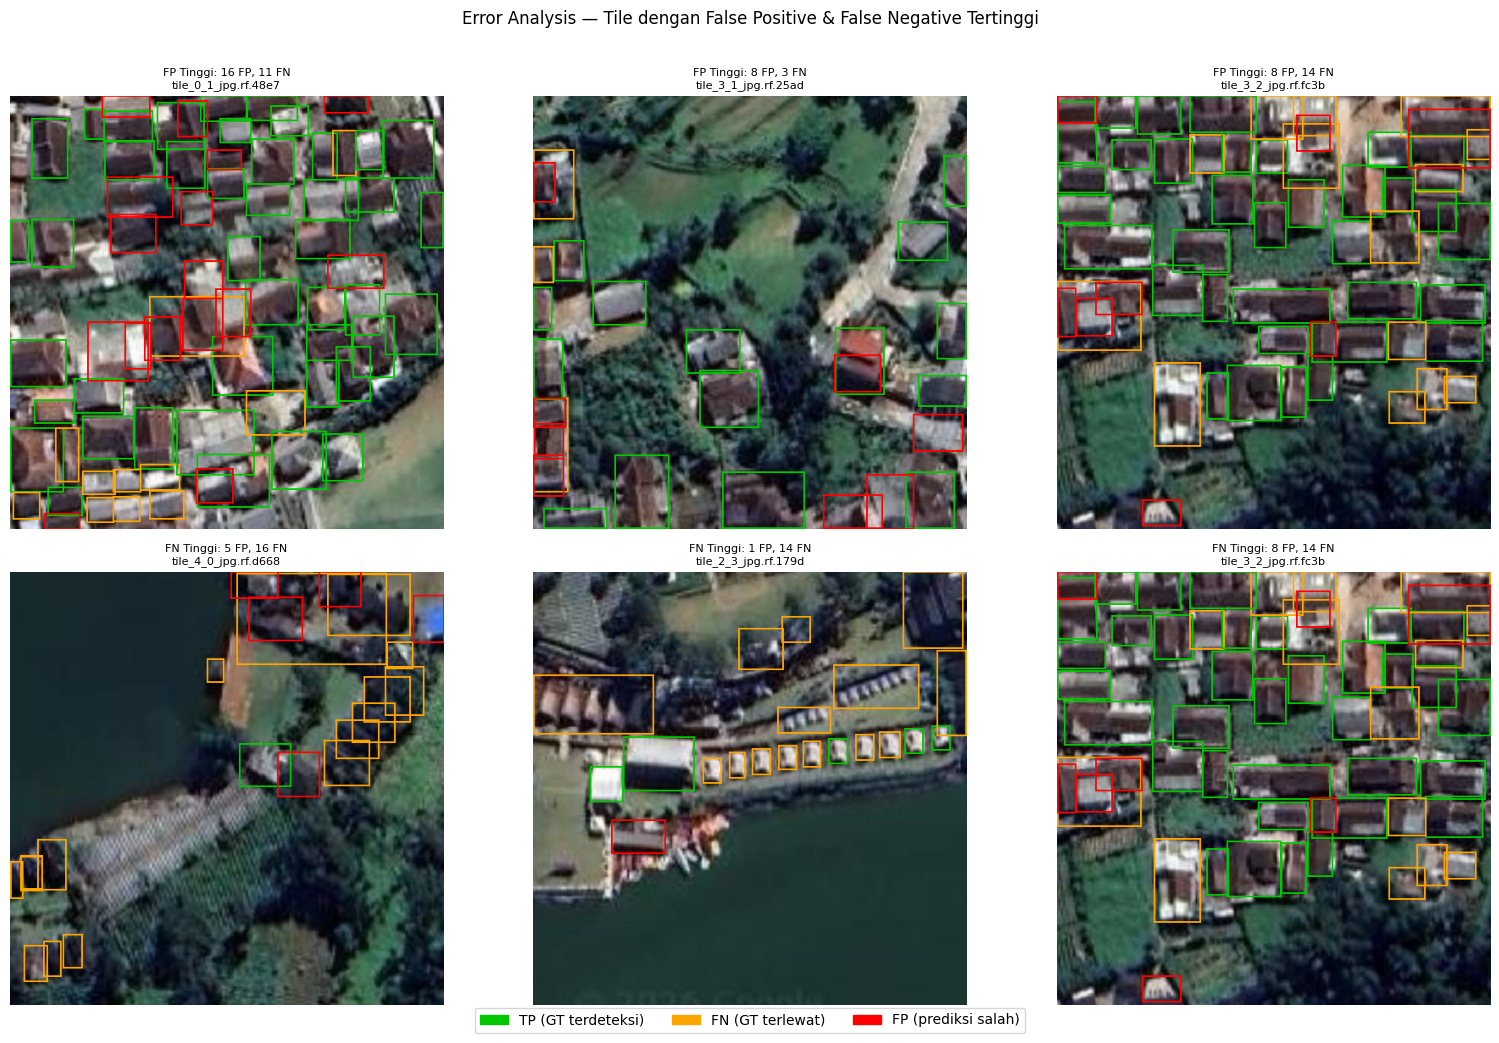

Error analysis tersimpan: error_analysis.png


In [ ]:
from ultralytics import YOLO
from PIL import Image, ImageDraw
import random, os
import matplotlib.pyplot as plt

print('Menjalankan error analysis di validation set...')

best_model_ea = YOLO(BEST_PT_SRC)
val_img_dir_ea = f'{dataset.location}/valid/images'
val_lbl_dir_ea = f'{dataset.location}/valid/labels'

val_imgs = [f for f in os.listdir(val_img_dir_ea) if f.endswith(('.jpg','.png'))]

fp_tiles  = []   # tile dengan false positive terbanyak
fn_tiles  = []   # tile dengan false negative terbanyak
tp_counts = []
fp_counts = []
fn_counts = []

IOU_THRESH_EA = 0.45

for img_file in val_imgs:
    img_path = os.path.join(val_img_dir_ea, img_file)
    lbl_path = os.path.join(val_lbl_dir_ea, img_file.rsplit('.',1)[0]+'.txt')

    # Ground truth
    gt_boxes = []
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                p = line.strip().split()
                if len(p) >= 5:
                    gt_boxes.append([float(p[1]),float(p[2]),float(p[3]),float(p[4])])

    # Prediksi
    res = best_model_ea.predict(img_path, conf=0.4, iou=IOU_THRESH_EA,
                                imgsz=512, verbose=False)
    pred_boxes = []
    for r in res:
        if r.boxes:
            for box in r.boxes:
                x = box.xywhn[0].tolist()
                pred_boxes.append(x[:4])

    # Hitung TP, FP, FN sederhana via IoU matching
    matched_gt   = set()
    matched_pred = set()

    for pi, pb in enumerate(pred_boxes):
        for gi, gb in enumerate(gt_boxes):
            if gi in matched_gt:
                continue
            # Hitung IoU sederhana
            px1 = pb[0]-pb[2]/2; py1 = pb[1]-pb[3]/2
            px2 = pb[0]+pb[2]/2; py2 = pb[1]+pb[3]/2
            gx1 = gb[0]-gb[2]/2; gy1 = gb[1]-gb[3]/2
            gx2 = gb[0]+gb[2]/2; gy2 = gb[1]+gb[3]/2
            ix1 = max(px1,gx1); iy1 = max(py1,gy1)
            ix2 = min(px2,gx2); iy2 = min(py2,gy2)
            inter = max(0,ix2-ix1) * max(0,iy2-iy1)
            union = pb[2]*pb[3] + gb[2]*gb[3] - inter
            iou   = inter/union if union > 0 else 0
            if iou >= IOU_THRESH_EA:
                matched_gt.add(gi)
                matched_pred.add(pi)
                break

    tp = len(matched_gt)
    fp = len(pred_boxes) - len(matched_pred)
    fn = len(gt_boxes)   - len(matched_gt)

    tp_counts.append(tp)
    fp_counts.append(fp)
    fn_counts.append(fn)

    if fp > 0:
        fp_tiles.append((img_file, fp, fn, gt_boxes, pred_boxes))
    if fn > 2:
        fn_tiles.append((img_file, fp, fn, gt_boxes, pred_boxes))

total_tp = sum(tp_counts)
total_fp = sum(fp_counts)
total_fn = sum(fn_counts)
precision_ea = total_tp/(total_tp+total_fp+1e-9)
recall_ea    = total_tp/(total_tp+total_fn+1e-9)

print(f'\n=== HASIL ERROR ANALYSIS (val set) ===')
print(f'  Total TP : {total_tp}')
print(f'  Total FP : {total_fp}  (bukan bangunan tapi dideteksi)')
print(f'  Total FN : {total_fn}  (bangunan asli tapi terlewat)')
print(f'  Precision: {precision_ea:.3f}')
print(f'  Recall   : {recall_ea:.3f}')

# Visualisasi 3 tile dengan FP terbanyak + 3 tile FN terbanyak
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

def draw_boxes_on_img(img_path, gt_boxes, pred_boxes, matched_gt, matched_pred):
    img  = Image.open(img_path).convert('RGB')
    draw = ImageDraw.Draw(img)
    w, h = img.size
    for gi, gb in enumerate(gt_boxes):
        x1=(gb[0]-gb[2]/2)*w; y1=(gb[1]-gb[3]/2)*h
        x2=(gb[0]+gb[2]/2)*w; y2=(gb[1]+gb[3]/2)*h
        color = (0,200,0) if gi in matched_gt else (255,165,0)
        draw.rectangle([x1,y1,x2,y2], outline=color, width=2)
    for pi, pb in enumerate(pred_boxes):
        x1=(pb[0]-pb[2]/2)*w; y1=(pb[1]-pb[3]/2)*h
        x2=(pb[0]+pb[2]/2)*w; y2=(pb[1]+pb[3]/2)*h
        if pi not in matched_pred:
            draw.rectangle([x1,y1,x2,y2], outline=(255,0,0), width=2)
    return img

# Baris 1: tile dengan FP terbanyak
fp_sorted = sorted(fp_tiles, key=lambda x: x[1], reverse=True)[:3]
for idx, (img_file, fp, fn, gt_boxes, pred_boxes) in enumerate(fp_sorted):
    img_path = os.path.join(val_img_dir_ea, img_file)
    matched_gt_set   = set()
    matched_pred_set = set()
    for pi, pb in enumerate(pred_boxes):
        for gi, gb in enumerate(gt_boxes):
            if gi in matched_gt_set: continue
            px1=pb[0]-pb[2]/2; py1=pb[1]-pb[3]/2; px2=pb[0]+pb[2]/2; py2=pb[1]+pb[3]/2
            gx1=gb[0]-gb[2]/2; gy1=gb[1]-gb[3]/2; gx2=gb[0]+gb[2]/2; gy2=gb[1]+gb[3]/2
            ix1=max(px1,gx1);iy1=max(py1,gy1);ix2=min(px2,gx2);iy2=min(py2,gy2)
            inter=max(0,ix2-ix1)*max(0,iy2-iy1)
            union=pb[2]*pb[3]+gb[2]*gb[3]-inter
            iou=inter/union if union>0 else 0
            if iou >= IOU_THRESH_EA:
                matched_gt_set.add(gi); matched_pred_set.add(pi); break
    vis_img = draw_boxes_on_img(img_path, gt_boxes, pred_boxes, matched_gt_set, matched_pred_set)
    axes[0,idx].imshow(vis_img)
    axes[0,idx].set_title(f'FP Tinggi: {fp} FP, {fn} FN\n{img_file[:20]}', fontsize=8)
    axes[0,idx].axis('off')

# Baris 2: tile dengan FN terbanyak
fn_sorted = sorted(fn_tiles, key=lambda x: x[2], reverse=True)[:3]
for idx, (img_file, fp, fn, gt_boxes, pred_boxes) in enumerate(fn_sorted):
    img_path = os.path.join(val_img_dir_ea, img_file)
    matched_gt_set = set(); matched_pred_set = set()
    for pi, pb in enumerate(pred_boxes):
        for gi, gb in enumerate(gt_boxes):
            if gi in matched_gt_set: continue
            px1=pb[0]-pb[2]/2; py1=pb[1]-pb[3]/2; px2=pb[0]+pb[2]/2; py2=pb[1]+pb[3]/2
            gx1=gb[0]-gb[2]/2; gy1=gb[1]-gb[3]/2; gx2=gb[0]+gb[2]/2; gy2=gb[1]+gb[3]/2
            ix1=max(px1,gx1);iy1=max(py1,gy1);ix2=min(px2,gx2);iy2=min(py2,gy2)
            inter=max(0,ix2-ix1)*max(0,iy2-iy1)
            union=pb[2]*pb[3]+gb[2]*gb[3]-inter
            iou=inter/union if union>0 else 0
            if iou >= IOU_THRESH_EA:
                matched_gt_set.add(gi); matched_pred_set.add(pi); break
    vis_img = draw_boxes_on_img(img_path, gt_boxes, pred_boxes, matched_gt_set, matched_pred_set)
    axes[1,idx].imshow(vis_img)
    axes[1,idx].set_title(f'FN Tinggi: {fp} FP, {fn} FN\n{img_file[:20]}', fontsize=8)
    axes[1,idx].axis('off')

legend_patches = [
    mpatches.Patch(color=(0,200/255,0),   label='TP (GT terdeteksi)'),
    mpatches.Patch(color=(255/255,165/255,0), label='FN (GT terlewat)'),
    mpatches.Patch(color=(1,0,0),         label='FP (prediksi salah)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Error Analysis — Tile dengan False Positive & False Negative Tertinggi',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/error_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print('Error analysis tersimpan: error_analysis.png')


---
# BAGIAN 5 — SIMPAN HASIL TRAINING KE DRIVE

## 5.1 — Simpan Weights & Semua Hasil

In [ ]:
import shutil, glob

# Weights
for fn, src in [('best.pt',BEST_PT_SRC),('last.pt',LAST_PT_SRC)]:
    dst = f'{WEIGHTS_DIR}/{fn}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"  ✅ {fn} ({os.path.getsize(dst)/1e6:.1f} MB)")

# Semua file dari folder training (kecuali weights subfolder)
print("\nMenyimpan hasil training...")
copied = 0
for fpath in glob.glob(f'{TRAIN_DIR}/*'):
    if os.path.isfile(fpath):
        dst = f'{TRAINING_RESULT_DIR}/{os.path.basename(fpath)}'
        shutil.copy(fpath, dst)
        copied += 1
        print(f"  ✅ {os.path.basename(fpath)}")

# Custom output
for fn in ['grafik_training_lengkap.png','semua_kurva_evaluasi.png',
           'report_card_evaluasi.png','sample_dataset.png']:
    src = f'{OUTPUT_DIR}/{fn}'
    if os.path.exists(src):
        shutil.copy(src, f'{TRAINING_RESULT_DIR}/{fn}')
        print(f"  ✅ {fn} (custom)")
        copied += 1

print(f"\n✅ {copied} file tersimpan ke: {TRAINING_RESULT_DIR}")


  ✅ best.pt (6.2 MB)
  ✅ last.pt (6.2 MB)

Menyimpan hasil training...
  ✅ BoxPR_curve.png
  ✅ BoxP_curve.png
  ✅ train_batch1.jpg
  ✅ train_batch2.jpg
  ✅ results.png
  ✅ confusion_matrix_normalized.png
  ✅ val_batch0_labels.jpg
  ✅ BoxF1_curve.png
  ✅ BoxR_curve.png
  ✅ train_batch0.jpg
  ✅ labels.jpg
  ✅ args.yaml
  ✅ confusion_matrix.png
  ✅ val_batch0_pred.jpg
  ✅ results.csv
  ✅ grafik_training_lengkap.png (custom)
  ✅ semua_kurva_evaluasi.png (custom)
  ✅ report_card_evaluasi.png (custom)
  ✅ sample_dataset.png (custom)

✅ 19 file tersimpan ke: /content/drive/MyDrive/SIG_Deteksi_Bangunan/training_results


---
# BAGIAN 6 — INFERENCE
> ⚠️ Pastikan `tiles/` dan `tiles_jpg/` sudah diisi sebelum menjalankan bagian ini.

## 6.1 — Cek Ketersediaan Tiles

In [ ]:
tif_tiles = [f for f in os.listdir(TILES_TIF_DIR) if f.endswith('.tif')] if os.path.exists(TILES_TIF_DIR) else []
jpg_tiles = [f for f in os.listdir(TILES_JPG_DIR) if f.endswith('.jpg')] if os.path.exists(TILES_JPG_DIR) else []

print(f"Tile .tif : {len(tif_tiles)}")
print(f"Tile .jpg : {len(jpg_tiles)}")

if len(tif_tiles) == 0 or len(jpg_tiles) == 0:
    raise ValueError("❌ Folder tiles kosong! Upload file .tif dan .jpg dulu ke Drive.")
if len(tif_tiles) != len(jpg_tiles):
    print(f"⚠️  Jumlah tidak sama — ada tile yang tidak punya pasangan")
else:
    print(f"✅ Semua tile siap ({len(jpg_tiles)} pasang)")


Tile .tif : 2184
Tile .jpg : 2184
✅ Semua tile siap (2184 pasang)


## 6.2 — Inference Semua Tile

In [ ]:
from ultralytics import YOLO
from tqdm import tqdm

CONFIDENCE = 0.4
model_inf  = YOLO(f'{WEIGHTS_DIR}/best.pt')
print(f"✅ Model loaded | Kelas: {model_inf.names}")
print(f"   Confidence threshold: {CONFIDENCE}")
print(f"   Mulai inference {len(jpg_tiles)} tile...\n")

all_detections = []
tile_no_tif    = []

for tile_file in tqdm(jpg_tiles, desc="Inference"):
    jpg_path = os.path.join(TILES_JPG_DIR, tile_file)
    tif_name = tile_file.replace('.jpg', '.tif')
    tif_path = os.path.join(TILES_TIF_DIR, tif_name)

    if not os.path.exists(tif_path):
        tile_no_tif.append(tile_file)
        continue

    results = model_inf.predict(source=jpg_path, conf=CONFIDENCE, imgsz=512, verbose=False)
    for result in results:
        if result.boxes is None or len(result.boxes) == 0:
            continue
        for box in result.boxes:
            xywhn = box.xywhn[0].tolist()
            all_detections.append({
                'tile_jpg': tile_file, 'tile_tif': tif_name,
                'x_center': xywhn[0], 'y_center': xywhn[1],
                'box_w': xywhn[2], 'box_h': xywhn[3],
                'confidence': float(box.conf[0])
            })

print(f"\n=== HASIL INFERENCE ===")
print(f"Tile diproses         : {len(jpg_tiles)-len(tile_no_tif)}")
print(f"Bangunan terdeteksi   : {len(all_detections)}")
if tile_no_tif:
    print(f"⚠️  {len(tile_no_tif)} tile tanpa pasangan .tif")


✅ Model loaded | Kelas: {0: 'bangunan'}
   Confidence threshold: 0.4
   Mulai inference 2184 tile...



Inference: 100%|██████████| 2184/2184 [00:53<00:00, 40.89it/s]


=== HASIL INFERENCE ===
Tile diproses         : 2184
Bangunan terdeteksi   : 4391


## CELL 6.25 — Statistik Inference (setelah inference selesai)

     STATISTIK INFERENCE

  Total tile diproses       : 2184
  Tile dengan deteksi       : 356 (16.3%)
  Tile tanpa deteksi        : 1828 (83.7%)
  Total bangunan terdeteksi : 4391
  Rata-rata deteksi/tile    : 12.3
  Max deteksi dalam 1 tile  : 69
  Confidence rata-rata      : 0.709
  Confidence >= 0.7         : 2525 (57.5%)
  Confidence 0.5-0.7        : 1265 (28.8%)
  Confidence < 0.5          : 601 (13.7%)


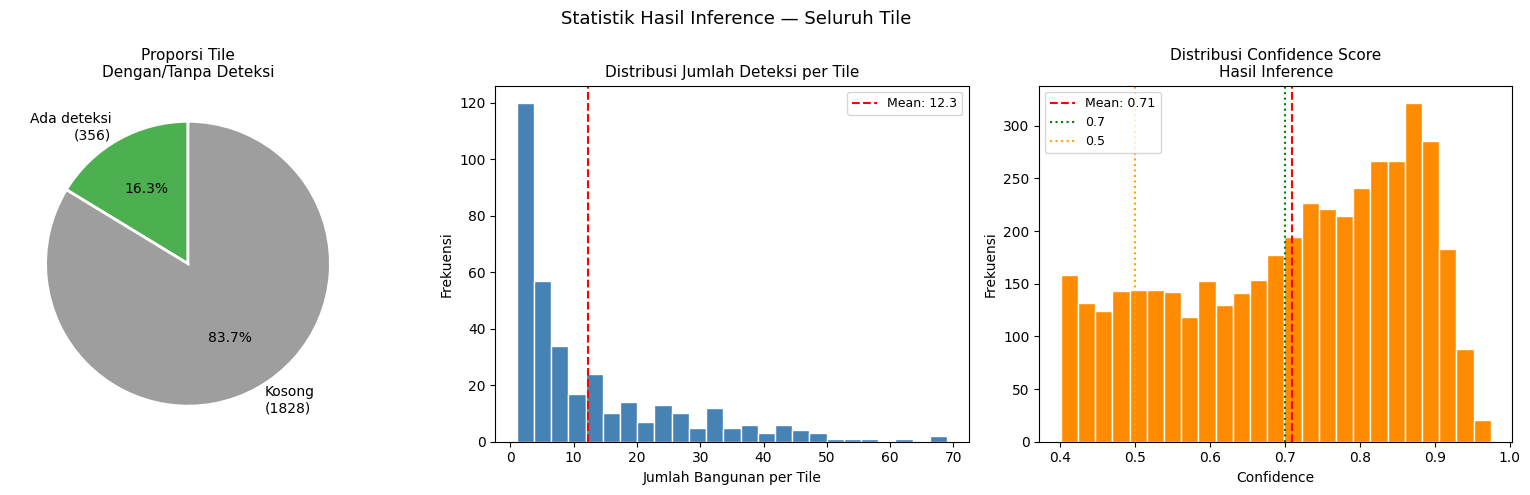

Statistik inference tersimpan: statistik_inference.png


In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

print('=' * 55)
print('     STATISTIK INFERENCE')
print('=' * 55)

conf_all = [d['confidence'] for d in all_detections]
tile_det  = Counter(d['tile_jpg'] for d in all_detections)
det_per_tile = list(tile_det.values())

n_tile_total   = len(jpg_tiles)
n_tile_deteksi = len(tile_det)
n_tile_kosong  = n_tile_total - n_tile_deteksi

print(f'\n  Total tile diproses       : {n_tile_total}')
print(f'  Tile dengan deteksi       : {n_tile_deteksi} ({n_tile_deteksi/n_tile_total*100:.1f}%)')
print(f'  Tile tanpa deteksi        : {n_tile_kosong} ({n_tile_kosong/n_tile_total*100:.1f}%)')
print(f'  Total bangunan terdeteksi : {len(all_detections)}')
print(f'  Rata-rata deteksi/tile    : {np.mean(det_per_tile):.1f}')
print(f'  Max deteksi dalam 1 tile  : {max(det_per_tile) if det_per_tile else 0}')
print(f'  Confidence rata-rata      : {np.mean(conf_all):.3f}')
print(f'  Confidence >= 0.7         : {sum(1 for c in conf_all if c>=0.7)} ({sum(1 for c in conf_all if c>=0.7)/len(conf_all)*100:.1f}%)')
print(f'  Confidence 0.5-0.7        : {sum(1 for c in conf_all if 0.5<=c<0.7)} ({sum(1 for c in conf_all if 0.5<=c<0.7)/len(conf_all)*100:.1f}%)')
print(f'  Confidence < 0.5          : {sum(1 for c in conf_all if c<0.5)} ({sum(1 for c in conf_all if c<0.5)/len(conf_all)*100:.1f}%)')

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie: tile deteksi vs kosong
axes[0].pie(
    [n_tile_deteksi, n_tile_kosong],
    labels=[f'Ada deteksi\n({n_tile_deteksi})', f'Kosong\n({n_tile_kosong})'],
    colors=['#4CAF50','#9E9E9E'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0].set_title('Proporsi Tile\nDengan/Tanpa Deteksi', fontsize=11)

# Histogram deteksi per tile
axes[1].hist(det_per_tile, bins=25, color='steelblue', edgecolor='white')
axes[1].axvline(np.mean(det_per_tile), color='red', linestyle='--',
                label=f'Mean: {np.mean(det_per_tile):.1f}')
axes[1].set_title('Distribusi Jumlah Deteksi per Tile', fontsize=11)
axes[1].set_xlabel('Jumlah Bangunan per Tile')
axes[1].set_ylabel('Frekuensi')
axes[1].legend(fontsize=9)

# Histogram confidence
axes[2].hist(conf_all, bins=25, color='darkorange', edgecolor='white')
axes[2].axvline(np.mean(conf_all), color='red', linestyle='--',
                label=f'Mean: {np.mean(conf_all):.2f}')
axes[2].axvline(0.7, color='green',  linestyle=':', label='0.7')
axes[2].axvline(0.5, color='orange', linestyle=':', label='0.5')
axes[2].set_title('Distribusi Confidence Score\nHasil Inference', fontsize=11)
axes[2].set_xlabel('Confidence')
axes[2].set_ylabel('Frekuensi')
axes[2].legend(fontsize=9)

plt.suptitle('Statistik Hasil Inference — Seluruh Tile', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/statistik_inference.png', dpi=150, bbox_inches='tight')
plt.show()
print('Statistik inference tersimpan: statistik_inference.png')


## 6.3 — Konversi Koordinat Pixel → Geografis

In [ ]:
import os
import rasterio
import rasterio.transform
from shapely.geometry import box as shapely_box
import geopandas as gpd
from tqdm import tqdm

geom_list = []; conf_list = []; tile_list = []; err_list = []

# --- OPTIMASI 1: Kelompokkan deteksi berdasarkan gambar yang sama ---
detections_by_tile = {}
for det in all_detections:
    tile = det['tile_tif']
    if tile not in detections_by_tile:
        detections_by_tile[tile] = []
    detections_by_tile[tile].append(det)

# --- OPTIMASI 2: Buka file gambar CUKUP 1 KALI per gambar ---
for tile_tif, detections in tqdm(detections_by_tile.items(), desc="Memproses Gambar"):
    tif_path = os.path.join(TILES_TIF_DIR, tile_tif)

    if not os.path.exists(tif_path):
        for det in detections:
            err_list.append(f"File tidak ditemukan: {tile_tif}")
        continue

    try:
        with rasterio.open(tif_path) as src:
            tf = src.transform
            w, h = src.width, src.height

            # Proses semua objek yang ada di dalam gambar ini sekaligus
            for det in detections:
                xc = det['x_center'] * w; yc = det['y_center'] * h
                bw = det['box_w'] * w; bh = det['box_h'] * h

                lon_min, lat_max = rasterio.transform.xy(tf, yc - bh/2, xc - bw/2)
                lon_max, lat_min = rasterio.transform.xy(tf, yc + bh/2, xc + bw/2)

                geom_list.append(shapely_box(lon_min, lat_min, lon_max, lat_max))
                conf_list.append(det['confidence'])
                tile_list.append(det['tile_jpg'])

    except Exception as e:
        for det in detections:
            err_list.append(f"{tile_tif}: {str(e)}")

# --- Pembuatan GeoJSON (Tetap sama namun lebih cepat) ---
gdf_bangunan = gpd.GeoDataFrame(
    {'confidence': conf_list, 'tile': tile_list, 'geometry': geom_list},
    crs='EPSG:4326'
)

# --- OPTIMASI 3: Cara cepat hitung titik tengah ---
centroids = gdf_bangunan.geometry.centroid
gdf_bangunan['lon'] = centroids.x
gdf_bangunan['lat'] = centroids.y

# Simpan ke GeoJSON
bangunan_path = f'{OUTPUT_DIR}/hasil_deteksi_bangunan.geojson'
gdf_bangunan.to_file(bangunan_path, driver='GeoJSON')

print(f"✅ {len(gdf_bangunan)} bangunan terkonversi")
if err_list:
    print(f"⚠️ {len(set(err_list))} file bermasalah/error")
print(f"✅ Tersimpan: {bangunan_path}")


Memproses Gambar: 100%|██████████| 356/356 [00:35<00:00,  9.95it/s]
Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



✅ 4391 bangunan terkonversi
✅ Tersimpan: /content/drive/MyDrive/SIG_Deteksi_Bangunan/output/hasil_deteksi_bangunan.geojson


---
# BAGIAN 7 — ANALISIS SPASIAL

## CELL 7.0 — Fix CRS Bug Sebelum Analisis Grid

In [ ]:
import geopandas as gpd
import numpy as np

print('=== CEK & FIX CRS ===')
print(f'CRS saat ini  : {gdf_bangunan.crs}')
print(f'Bounds        : {[round(b,4) for b in gdf_bangunan.total_bounds]}')

# Fix CRS ke EPSG:4326 kalau belum
if gdf_bangunan.crs is None or '4326' not in str(gdf_bangunan.crs):
    print('Konversi ke EPSG:4326...')
    gdf_bangunan = gdf_bangunan.to_crs('EPSG:4326')
    print('Konversi selesai')
else:
    print('CRS sudah EPSG:4326')

# Hitung centroid dengan CRS yang benar (proyeksi metrik dulu)
gdf_bangunan['lon'] = gdf_bangunan.to_crs('EPSG:32748').geometry.centroid.to_crs('EPSG:4326').x
gdf_bangunan['lat'] = gdf_bangunan.to_crs('EPSG:32748').geometry.centroid.to_crs('EPSG:4326').y

bounds = gdf_bangunan.total_bounds
print(f'Bounds setelah fix: {[round(b,4) for b in bounds]}')

# Validasi masuk akal untuk Indonesia
lon_ok = 95 <= bounds[0] <= 141 and 95 <= bounds[2] <= 141
lat_ok = -11 <= bounds[1] <= 6  and -11 <= bounds[3] <= 6
if not lon_ok or not lat_ok:
    raise ValueError(f'Bounds tidak wajar untuk Indonesia: {bounds}')
print('Bounds valid untuk Indonesia')

# Estimasi ukuran grid yang aman
for gs in [0.001, 0.002, 0.005]:
    nx = len(np.arange(bounds[0], bounds[2]+gs, gs))
    ny = len(np.arange(bounds[1], bounds[3]+gs, gs))
    total = nx * ny
    status = 'AMAN' if total < 15000 else 'BANYAK' if total < 50000 else 'TERLALU BANYAK'
    print(f'  Grid {gs} (~{round(gs*111000)}m): {total:,} sel — {status}')


=== CEK & FIX CRS ===
CRS saat ini  : EPSG:4326
Bounds        : [np.float64(107.4553), np.float64(-7.2121), np.float64(107.5548), np.float64(-7.1682)]
CRS sudah EPSG:4326
Bounds setelah fix: [np.float64(107.4553), np.float64(-7.2121), np.float64(107.5548), np.float64(-7.1682)]
Bounds valid untuk Indonesia
  Grid 0.001 (~111m): 4,545 sel — AMAN
  Grid 0.002 (~222m): 1,173 sel — AMAN
  Grid 0.005 (~555m): 210 sel — AMAN


## 7.1 — Analisis Kepadatan Grid + Klasifikasi 4 Kelas

In [ ]:
import numpy as np
from shapely.ops import unary_union

GRID_SIZE_DEG = 0.001  # ~111 meter
print(f"Grid: ~{GRID_SIZE_DEG*111000:.0f}m per sel")

bounds  = gdf_bangunan.total_bounds
x_edges = np.arange(bounds[0], bounds[2]+GRID_SIZE_DEG, GRID_SIZE_DEG)
y_edges = np.arange(bounds[1], bounds[3]+GRID_SIZE_DEG, GRID_SIZE_DEG)

grid_cells = [shapely_box(x,y,x+GRID_SIZE_DEG,y+GRID_SIZE_DEG)
              for x in x_edges for y in y_edges]
grid_gdf = gpd.GeoDataFrame({'geometry':grid_cells}, crs='EPSG:4326')

# Spatial join — hitung bangunan per sel
centroids = gpd.GeoDataFrame({'geometry':gdf_bangunan.geometry.centroid}, crs='EPSG:4326')
joined    = gpd.sjoin(centroids, grid_gdf, how='left', predicate='within')
counts    = joined.groupby('index_right').size().reset_index(name='count')
grid_gdf['count'] = 0
grid_gdf.loc[counts['index_right'].values,'count'] = counts['count'].values

# Klasifikasi 4 kelas
def kelas_fn(c):
    if c == 0:   return 0
    elif c <= 4: return 1
    elif c <= 9: return 2
    else:        return 3

grid_gdf['kelas'] = grid_gdf['count'].apply(kelas_fn)
grid_gdf['kelas_nama'] = grid_gdf['kelas'].map({
    0:'Tidak Ada', 1:'Jarang (1-4)', 2:'Sedang (5-9)', 3:'Tinggi (≥10)'})

# Dissolve per kelas
hasil_kelas = []
for kn, grp in grid_gdf[grid_gdf['kelas']>0].groupby('kelas_nama'):
    hasil_kelas.append(gpd.GeoDataFrame({
        'kelas':[kn],'bangunan':[grp['count'].sum()],
        'geometry':[unary_union(grp.geometry)]}, crs='EPSG:4326'))

kepadatan_gdf = gpd.GeoDataFrame(
    pd.concat(hasil_kelas,ignore_index=True), crs='EPSG:4326') if hasil_kelas else     gpd.GeoDataFrame(geometry=[], crs='EPSG:4326')

if len(kepadatan_gdf):
    kepadatan_gdf['luas_ha'] = kepadatan_gdf.to_crs('EPSG:32748').geometry.area/10000

# Area permukiman (kelas sedang + tinggi)
permukiman_cells = grid_gdf[grid_gdf['kelas']>=2]
if len(permukiman_cells):
    perm_dissolved = gpd.GeoDataFrame(
        geometry=[unary_union(permukiman_cells.geometry)],crs='EPSG:4326'
    ).explode(index_parts=False).reset_index(drop=True)
    perm_dissolved['luas_ha'] = perm_dissolved.to_crs('EPSG:32748').geometry.area/10000
else:
    perm_dissolved = gpd.GeoDataFrame(geometry=[],crs='EPSG:4326')

# Simpan GeoJSON
grid_gdf.to_file(f'{OUTPUT_DIR}/grid_kepadatan.geojson', driver='GeoJSON')
kepadatan_gdf.to_file(f'{OUTPUT_DIR}/kepadatan_bertingkat.geojson', driver='GeoJSON')
perm_dissolved.to_file(f'{OUTPUT_DIR}/area_permukiman.geojson', driver='GeoJSON')

print(f"\n=== HASIL KEPADATAN ===")
for kn, grp in grid_gdf[grid_gdf['kelas']>0].groupby('kelas_nama'):
    print(f"  {kn:<15}: {len(grp)} sel | {grp['count'].sum()} bangunan")
print(f"\n✅ GeoJSON kepadatan & permukiman tersimpan")


Grid: ~111m per sel


Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




=== HASIL KEPADATAN ===
  Jarang (1-4)   : 142 sel | 265 bangunan
  Sedang (5-9)   : 66 sel | 460 bangunan
  Tinggi (≥10)   : 143 sel | 3666 bangunan

✅ GeoJSON kepadatan & permukiman tersimpan


## 7.2 — Statistik Lanjutan

In [ ]:
import pandas as pd

gdf_metric = gdf_bangunan.to_crs('EPSG:32748')
gdf_metric['luas_m2'] = gdf_metric.geometry.area

total_atap  = gdf_metric['luas_m2'].sum()
rata_atap   = gdf_metric['luas_m2'].mean()
median_atap = gdf_metric['luas_m2'].median()

bounds_m    = gdf_metric.total_bounds
aoi_m2      = (bounds_m[2]-bounds_m[0])*(bounds_m[3]-bounds_m[1])
persen_tb   = total_atap/aoi_m2*100
kepadatan   = len(gdf_bangunan)/(aoi_m2/1e6)

bins   = [0,25,50,100,200,500,float('inf')]
labels = ['<25m²','25-50m²','50-100m²','100-200m²','200-500m²','>500m²']
gdf_metric['ukuran_kat'] = pd.cut(gdf_metric['luas_m2'],bins=bins,labels=labels)
dist_uk = gdf_metric['ukuran_kat'].value_counts().sort_index()

print("="*52)
print("     STATISTIK SPASIAL LANJUTAN")
print("="*52)
print(f"\n── Bangunan ──")
print(f"  Total terdeteksi        : {len(gdf_bangunan)}")
print(f"  Confidence rata-rata    : {gdf_bangunan['confidence'].mean():.3f}")
print(f"  Luas atap total         : {total_atap:,.0f} m² ({total_atap/10000:.2f} ha)")
print(f"  Rata-rata luas per bgn  : {rata_atap:.1f} m²")
print(f"  Median luas per bgn     : {median_atap:.1f} m²")
print(f"\n── Tutupan Lahan ──")
print(f"  Luas AOI analisis       : {aoi_m2/1e6:.2f} km²")
print(f"  Kepadatan               : {kepadatan:.1f} bangunan/km²")
print(f"  Lahan terbangun         : {persen_tb:.2f}%")
print(f"  Non-terbangun           : {100-persen_tb:.2f}%")
print(f"\n── Distribusi Ukuran Bangunan ──")
for kat, jml in dist_uk.items():
    pct = jml/len(gdf_metric)*100
    bar = '█'*int(pct/2)
    print(f"  {kat:<12}: {jml:4d} ({pct:5.1f}%) {bar}")


     STATISTIK SPASIAL LANJUTAN

── Bangunan ──
  Total terdeteksi        : 4391
  Confidence rata-rata    : 0.709
  Luas atap total         : 633,059 m² (63.31 ha)
  Rata-rata luas per bgn  : 144.2 m²
  Median luas per bgn     : 117.0 m²

── Tutupan Lahan ──
  Luas AOI analisis       : 53.51 km²
  Kepadatan               : 82.1 bangunan/km²
  Lahan terbangun         : 1.18%
  Non-terbangun           : 98.82%

── Distribusi Ukuran Bangunan ──
  <25m²       :   15 (  0.3%) 
  25-50m²     :  277 (  6.3%) ███
  50-100m²    : 1434 ( 32.7%) ████████████████
  100-200m²   : 1893 ( 43.1%) █████████████████████
  200-500m²   :  719 ( 16.4%) ████████
  >500m²      :   53 (  1.2%) 


## CELL 7.25 — Tabel Ringkasan Lengkap untuk Paper

In [ ]:
import pandas as pd

print('=' * 65)
print('     TABEL RINGKASAN HASIL — SIAP UNTUK PAPER')
print('=' * 65)

# Tabel 1: Dataset Summary
print('\n[TABEL 1] Dataset')
tbl1 = pd.DataFrame({
    'Item'   : ['Total tile asli', 'Tile training', 'Tile validasi', 'Tile test',
                'Total setelah augmentasi', 'Total anotasi (bbox)',
                'Kelas', 'Ukuran tile', 'Resolusi citra', 'CRS'],
    'Nilai'  : [f'{n_train+n_val+n_test}', str(n_train), str(n_val), str(n_test),
                f'{n_train+n_val+n_test} (est.)', str(bbox_train+bbox_val+bbox_test),
                '1 (bangunan)', '512×512 pixel', '~0.6 m/pixel (skala 1:2000)', 'EPSG:4326'],
})
print(tbl1.to_string(index=False))

# Tabel 2: Model Summary
print('\n\n[TABEL 2] Model & Training')
tbl2 = pd.DataFrame({
    'Parameter'  : ['Arsitektur', 'Pre-trained', 'Optimizer', 'Epochs', 'Best Epoch',
                    'Batch Size', 'Image Size', 'Patience', 'Training Time', 'GPU'],
    'Nilai'      : ['YOLOv8n (nano)', 'COCO', 'Adam (default Ultralytics)',
                    '50', str(int(df.loc[df[col_map.get("map50","")].idxmax(),"epoch"])) if "map50" in col_map else "-",
                    '16', '512', '10', '~0.1 jam (T4 GPU)', 'Tesla T4 (14.9 GB)'],
})
print(tbl2.to_string(index=False))

# Tabel 3: Metrik Evaluasi
print('\n\n[TABEL 3] Metrik Evaluasi')
tbl3 = pd.DataFrame({
    'Metrik'      : ['mAP@50', 'mAP@50-95', 'Precision', 'Recall', 'F1-Score',
                     'Inference/image'],
    'Nilai'       : [f'{eval_metrics["mAP50"]:.4f}',
                     f'{eval_metrics["mAP50_95"]:.4f}',
                     f'{eval_metrics["Precision"]:.4f}',
                     f'{eval_metrics["Recall"]:.4f}',
                     f'{eval_metrics["F1"]:.4f}',
                     '1.3 ms'],
    'Keterangan'  : ['Akurasi deteksi pada IoU=0.5',
                     'Rata-rata di IoU 0.5-0.95',
                     'Presisi prediksi bangunan',
                     'Cakupan bangunan asli',
                     'Harmonic mean P & R',
                     'Di GPU Tesla T4'],
})
print(tbl3.to_string(index=False))

# Tabel 4: Hasil Spasial
print('\n\n[TABEL 4] Hasil Analisis Spasial')
perm_luas = float(perm_dissolved['luas_ha'].sum()) if len(perm_dissolved) else 0
tbl4 = pd.DataFrame({
    'Item'  : ['Total bangunan terdeteksi', 'Luas atap total', 'Rata-rata luas/bangunan',
               'Median luas/bangunan', 'Luas AOI analisis', 'Kepadatan bangunan',
               'Lahan terbangun', 'Area permukiman (kelas sedang+tinggi)',
               'Kelas Jarang (1-4 bgn/sel)', 'Kelas Sedang (5-9 bgn/sel)', 'Kelas Tinggi (>=10 bgn/sel)'],
    'Nilai' : [f'{len(gdf_bangunan)} unit',
               f'{total_atap:,.0f} m² ({total_atap/10000:.2f} ha)',
               f'{rata_atap:.1f} m²',
               f'{float(median_atap):.1f} m²',
               f'{aoi_m2/1e6:.2f} km²',
               f'{kepadatan:.1f} bangunan/km²',
               f'{persen_tb:.2f}%',
               f'{perm_luas:.2f} ha',
               f'{len(grid_gdf[grid_gdf["kelas"]==1])} sel grid',
               f'{len(grid_gdf[grid_gdf["kelas"]==2])} sel grid',
               f'{len(grid_gdf[grid_gdf["kelas"]==3])} sel grid'],
})
print(tbl4.to_string(index=False))

# Simpan semua tabel ke CSV untuk referensi paper
tbl1.to_csv(f'{OUTPUT_DIR}/tabel_dataset.csv',    index=False)
tbl2.to_csv(f'{OUTPUT_DIR}/tabel_model.csv',      index=False)
tbl3.to_csv(f'{OUTPUT_DIR}/tabel_metrik.csv',     index=False)
tbl4.to_csv(f'{OUTPUT_DIR}/tabel_spasial.csv',    index=False)
print('\n\nSemua tabel tersimpan sebagai CSV di folder output/')
print('Langsung bisa dipakai sebagai referensi Bab 3 & 4 paper')


     TABEL RINGKASAN HASIL — SIAP UNTUK PAPER

[TABEL 1] Dataset
                    Item                       Nilai
         Total tile asli                         562
           Tile training                         519
           Tile validasi                          32
               Tile test                          11
Total setelah augmentasi                  562 (est.)
    Total anotasi (bbox)                        5629
                   Kelas                1 (bangunan)
             Ukuran tile               512×512 pixel
          Resolusi citra ~0.6 m/pixel (skala 1:2000)
                     CRS                   EPSG:4326


[TABEL 2] Model & Training
    Parameter                      Nilai
   Arsitektur             YOLOv8n (nano)
  Pre-trained                       COCO
    Optimizer Adam (default Ultralytics)
       Epochs                         50
   Best Epoch                         42
   Batch Size                         16
   Image Size                       

## 7.3 — Visualisasi Peta Kepadatan & Statistik

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



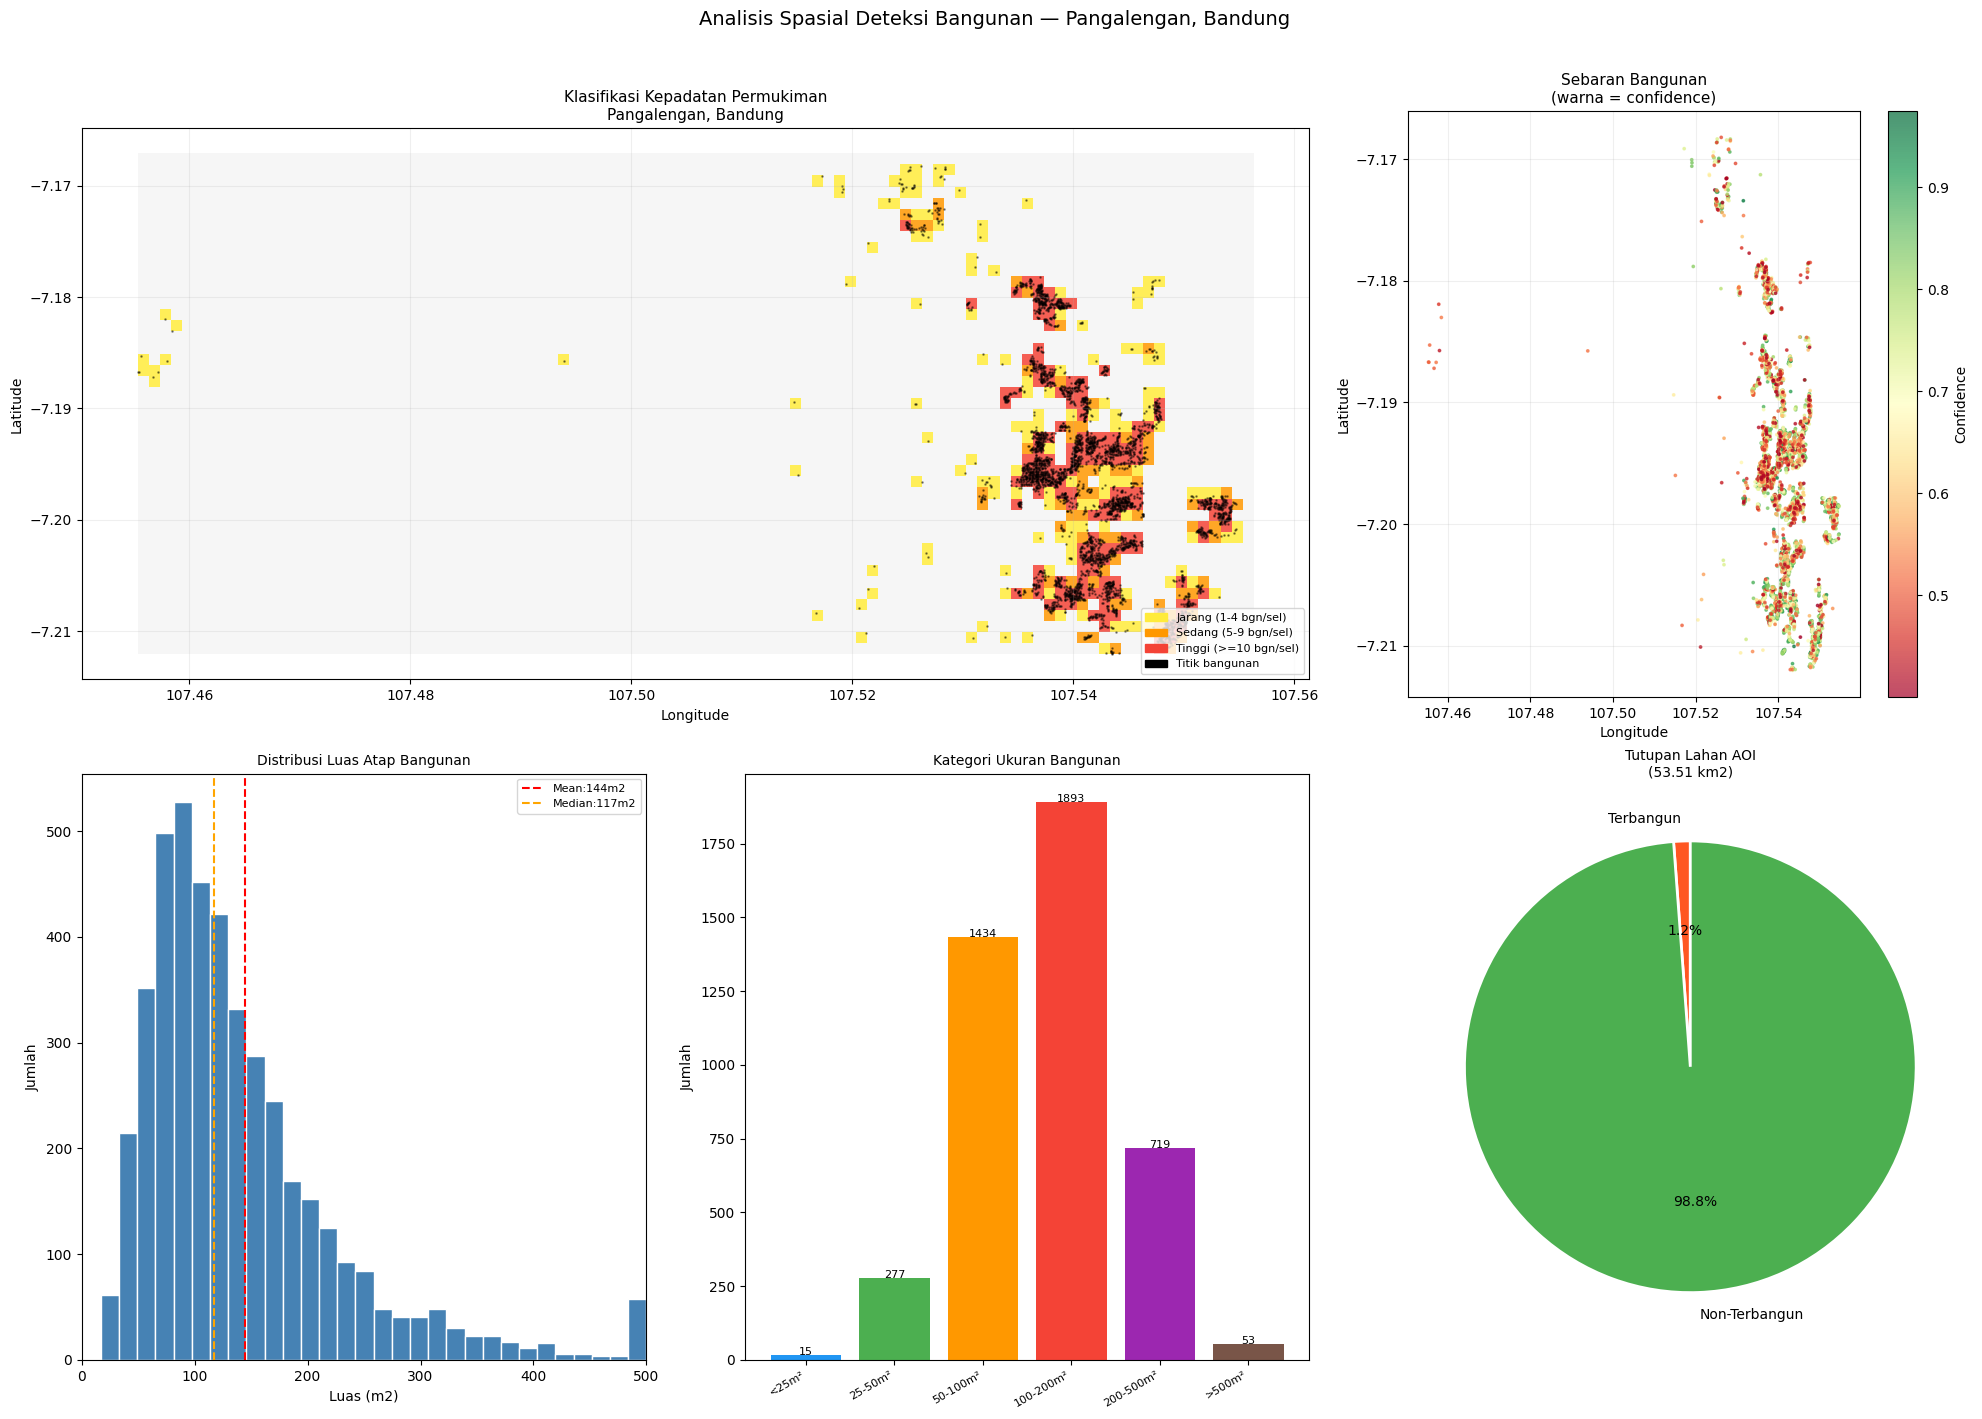

Peta analisis lengkap tersimpan


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(20, 14))

# ── 1. Peta kepadatan bertingkat
ax1 = fig.add_subplot(2, 3, (1, 2))
color_map = {0: '#F5F5F5', 1: '#FFEB3B', 2: '#FF9800', 3: '#F44336'}
for kls in [0, 1, 2, 3]:
    sub = grid_gdf[grid_gdf['kelas'] == kls]
    if len(sub):
        sub.plot(ax=ax1, color=color_map[kls], edgecolor='none', alpha=0.85)
gdf_bangunan.geometry.centroid.plot(ax=ax1, color='black', markersize=0.8, alpha=0.4)
ax1.set_title('Klasifikasi Kepadatan Permukiman\nPangalengan, Bandung', fontsize=11)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.grid(True, alpha=0.2)
legend_patches = [
    mpatches.Patch(color='#FFEB3B', label='Jarang (1-4 bgn/sel)'),
    mpatches.Patch(color='#FF9800', label='Sedang (5-9 bgn/sel)'),
    mpatches.Patch(color='#F44336', label='Tinggi (>=10 bgn/sel)'),
    mpatches.Patch(color='black',   label='Titik bangunan'),
]
ax1.legend(handles=legend_patches, loc='lower right', fontsize=8)

# ── 2. Peta sebaran bangunan (warna confidence)
ax2 = fig.add_subplot(2, 3, 3)
sc = ax2.scatter(
    gdf_bangunan['lon'], gdf_bangunan['lat'],
    c=gdf_bangunan['confidence'], cmap='RdYlGn', s=3, alpha=0.7
)
plt.colorbar(sc, ax=ax2, label='Confidence')
ax2.set_title('Sebaran Bangunan\n(warna = confidence)', fontsize=11)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.grid(True, alpha=0.2)

# ── 3. Distribusi ukuran bangunan
ax3 = fig.add_subplot(2, 3, 4)
ax3.hist(
    gdf_metric['luas_m2'].clip(upper=500),
    bins=30, color='steelblue', edgecolor='white'
)
ax3.axvline(rata_atap,   color='red',    linestyle='--', label=f'Mean:{rata_atap:.0f}m2')
ax3.axvline(median_atap, color='orange', linestyle='--', label=f'Median:{median_atap:.0f}m2')
ax3.set_title('Distribusi Luas Atap Bangunan', fontsize=10)
ax3.set_xlabel('Luas (m2)')
ax3.set_ylabel('Jumlah')
ax3.legend(fontsize=8)
ax3.set_xlim(0, 500)

# ── 4. Bar chart kategori ukuran
ax4 = fig.add_subplot(2, 3, 5)
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#795548']
bars = ax4.bar(
    range(len(dist_uk)),
    dist_uk.values,
    color=colors_bar[:len(dist_uk)]
)
ax4.set_xticks(range(len(dist_uk)))
ax4.set_xticklabels(dist_uk.index, rotation=30, ha='right', fontsize=8)
ax4.set_title('Kategori Ukuran Bangunan', fontsize=10)
ax4.set_ylabel('Jumlah')
for b, v in zip(bars, dist_uk.values):
    ax4.text(b.get_x() + b.get_width()/2, v + 0.3, str(v), ha='center', fontsize=8)

# ── 5. Pie chart tutupan lahan
ax5 = fig.add_subplot(2, 3, 6)
pie_labels = ['Terbangun', 'Non-Terbangun']
pie_sizes  = [persen_tb, 100 - persen_tb]
pie_colors = ['#FF5722', '#4CAF50']
ax5.pie(
    pie_sizes,
    labels=pie_labels,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
ax5.set_title(f'Tutupan Lahan AOI\n({aoi_m2/1e6:.2f} km2)', fontsize=10)

plt.suptitle(
    'Analisis Spasial Deteksi Bangunan — Pangalengan, Bandung',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/peta_analisis_lengkap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Peta analisis lengkap tersimpan")

---
# BAGIAN 8 — PETA INTERAKTIF

## 8.1 — Buat Peta Interaktif Folium

In [ ]:
import folium
from folium.plugins import MiniMap, MarkerCluster
from IPython.display import IFrame

center = [gdf_bangunan['lat'].mean(), gdf_bangunan['lon'].mean()]

m = folium.Map(
    location=center, zoom_start=15,
    tiles='https://mt0.google.com/vt/lyrs=s&hl=en&x={x}&y={y}&z={z}&key=',
    attr='Google Satellite'
)

# Layer area permukiman
if len(perm_dissolved):
    folium.GeoJson(
        perm_dissolved.__geo_interface__, name='Area Permukiman',
        style_function=lambda x:{
            'fillColor':'#FFA500','color':'#FF6600','weight':2,'fillOpacity':0.35}
    ).add_to(m)

# Layer kepadatan bertingkat
kelas_style = {
    'Jarang (1-4)' :{'fillColor':'#FFEB3B','color':'#CCCC00','weight':1,'fillOpacity':0.5},
    'Sedang (5-9)' :{'fillColor':'#FF9800','color':'#E65100','weight':1,'fillOpacity':0.5},
    'Tinggi (≥10)' :{'fillColor':'#F44336','color':'#B71C1C','weight':1,'fillOpacity':0.5},
}
for kn, style in kelas_style.items():
    sub = grid_gdf[grid_gdf['kelas_nama']==kn]
    if len(sub):
        folium.GeoJson(
            sub.__geo_interface__, name=f'Kepadatan {kn}',
            style_function=lambda x,s=style:s,
            tooltip=folium.GeoJsonTooltip(['count','kelas_nama'],
                                          ['Bangunan:','Kelas:']),
            show=False
        ).add_to(m)

# Layer bangunan
if len(gdf_bangunan) <= 8000:
    for _, row in gdf_bangunan.iterrows():
        coords = [[c[1],c[0]] for c in row.geometry.exterior.coords]
        color  = ('#00CC00' if row['confidence']>=0.7 else
                  '#FFAA00' if row['confidence']>=0.5 else '#FF3300')
        folium.Polygon(
            locations=coords, color=color, weight=1.5,
            fill=True, fill_color=color, fill_opacity=0.25,
            tooltip=f"Conf: {row['confidence']:.2f} | {row['tile']}"
        ).add_to(m)
else:
    mc = MarkerCluster(name='Bangunan Terdeteksi')
    for _, row in gdf_bangunan.iterrows():
        folium.CircleMarker(
            location=[row['lat'],row['lon']],radius=3,
            color='red',fill=True,
            popup=f"Conf: {row['confidence']:.2f}"
        ).add_to(mc)
    mc.add_to(m)

folium.LayerControl().add_to(m)
MiniMap(toggle_display=True).add_to(m)

# Info box
m.get_root().html.add_child(folium.Element(f"""
<div style="position:fixed;top:10px;right:10px;z-index:1000;
     background:rgba(255,255,255,0.93);padding:12px 16px;
     border-radius:10px;border:1px solid #999;font-size:13px;
     font-family:Arial;box-shadow:2px 2px 6px rgba(0,0,0,0.2);">
  <b>🛰️ Deteksi Bangunan — Pangalengan</b><br>
  <hr style="margin:6px 0">
  🏠 Bangunan terdeteksi : <b>{len(gdf_bangunan)}</b><br>
  🗺️ Area permukiman     : <b>{len(perm_dissolved)} cluster</b><br>
  📊 Conf rata-rata      : <b>{gdf_bangunan['confidence'].mean():.3f}</b><br>
  📐 mAP@50              : <b>{eval_metrics['mAP50']:.3f}</b>
</div>"""))

# Legenda
m.get_root().html.add_child(folium.Element("""
<div style="position:fixed;bottom:60px;left:50px;z-index:1000;
     background:white;padding:12px 16px;border-radius:10px;
     border:2px solid #666;font-size:12px;font-family:Arial;
     box-shadow:2px 2px 6px rgba(0,0,0,0.2);">
  <b>Legenda</b><br><br>
  <span style="color:#00CC00;font-size:15px;">■</span> Bangunan (conf ≥ 0.7)<br>
  <span style="color:#FFAA00;font-size:15px;">■</span> Bangunan (conf 0.5–0.7)<br>
  <span style="color:#FF3300;font-size:15px;">■</span> Bangunan (conf < 0.5)<br>
  <span style="color:#FFA500;font-size:15px;">■</span> Area Permukiman<br>
  <span style="color:#FFEB3B;font-size:15px;">■</span> Kepadatan Jarang<br>
  <span style="color:#FF9800;font-size:15px;">■</span> Kepadatan Sedang<br>
  <span style="color:#F44336;font-size:15px;">■</span> Kepadatan Tinggi
</div>"""))

map_path = f'{OUTPUT_DIR}/peta_interaktif.html'
m.save(map_path)
print(f"✅ Peta interaktif tersimpan: {map_path}")
IFrame(map_path, width='100%', height=550)


✅ Peta interaktif tersimpan: /content/drive/MyDrive/SIG_Deteksi_Bangunan/output/peta_interaktif.html


---
# BAGIAN 9 — SIMPAN SEMUA OUTPUT KE DRIVE

## 9.1 — Copy Semua File Output

In [ ]:
import shutil

output_files = {
    # GeoJSON untuk QGIS
    'hasil_deteksi_bangunan.geojson' : '✅ GeoJSON bangunan (QGIS)',
    'area_permukiman.geojson'        : '✅ GeoJSON area permukiman (QGIS)',
    'grid_kepadatan.geojson'         : '✅ GeoJSON grid kepadatan (QGIS)',
    'kepadatan_bertingkat.geojson'   : '✅ GeoJSON 4 kelas kepadatan (QGIS)',
    # Visualisasi
    'peta_interaktif.html'           : '🌐 Peta interaktif (browser)',
    'peta_analisis_lengkap.png'      : '📊 Peta analisis lengkap (laporan)',
    'report_card_evaluasi.png'       : '📋 Report card evaluasi (laporan)',
    'grafik_training_lengkap.png'    : '📈 Grafik training (laporan)',
    'semua_kurva_evaluasi.png'       : '📈 Kurva PR/F1/P/R (laporan)',
    'sample_dataset.png'             : '🖼️ Sample dataset (laporan)',
}

print("Menyimpan semua output ke Drive...")
print(f"Tujuan: {OUTPUT_DIR}\n")

copied = 0
for filename, keterangan in output_files.items():
    src = f'{OUTPUT_DIR}/{filename}'
    # File sudah di OUTPUT_DIR, pastikan ada
    if os.path.exists(src):
        print(f"  {keterangan} — {filename}")
        copied += 1
    else:
        print(f"  ❌ Tidak ditemukan: {filename}")

print(f"\n✅ {copied} file tersedia di: {OUTPUT_DIR}")
print("\n=== FILE UNTUK QGIS ===")
for f in ['hasil_deteksi_bangunan.geojson','area_permukiman.geojson',
          'grid_kepadatan.geojson','kepadatan_bertingkat.geojson']:
    path = f'{OUTPUT_DIR}/{f}'
    sz   = os.path.getsize(path)/1024 if os.path.exists(path) else 0
    print(f"  📁 {f} ({sz:.0f} KB)")

print("\n=== FILE UNTUK LAPORAN ===")
for f in ['peta_interaktif.html','peta_analisis_lengkap.png',
          'report_card_evaluasi.png','grafik_training_lengkap.png']:
    path = f'{OUTPUT_DIR}/{f}'
    sz   = os.path.getsize(path)/1024 if os.path.exists(path) else 0
    print(f"  📄 {f} ({sz:.0f} KB)")


Menyimpan semua output ke Drive...
Tujuan: /content/drive/MyDrive/SIG_Deteksi_Bangunan/output

  ✅ GeoJSON bangunan (QGIS) — hasil_deteksi_bangunan.geojson
  ✅ GeoJSON area permukiman (QGIS) — area_permukiman.geojson
  ✅ GeoJSON grid kepadatan (QGIS) — grid_kepadatan.geojson
  ✅ GeoJSON 4 kelas kepadatan (QGIS) — kepadatan_bertingkat.geojson
  🌐 Peta interaktif (browser) — peta_interaktif.html
  📊 Peta analisis lengkap (laporan) — peta_analisis_lengkap.png
  📋 Report card evaluasi (laporan) — report_card_evaluasi.png
  📈 Grafik training (laporan) — grafik_training_lengkap.png
  📈 Kurva PR/F1/P/R (laporan) — semua_kurva_evaluasi.png
  🖼️ Sample dataset (laporan) — sample_dataset.png

✅ 10 file tersedia di: /content/drive/MyDrive/SIG_Deteksi_Bangunan/output

=== FILE UNTUK QGIS ===
  📁 hasil_deteksi_bangunan.geojson (1876 KB)
  📁 area_permukiman.geojson (17 KB)
  📁 grid_kepadatan.geojson (1660 KB)
  📁 kepadatan_bertingkat.geojson (50 KB)

=== FILE UNTUK LAPORAN ===
  📄 peta_interaktif.ht

## 9.2 — Verifikasi Final Isi Folder Drive

In [ ]:
print(f"=== ISI FOLDER DRIVE: SIG_Deteksi_Bangunan ===\n")
for subdir in ['weights','training_results','output','tiles','tiles_jpg','dataset']:
    full = f'{DRIVE_BASE}/{subdir}'
    if os.path.exists(full):
        files = [f for f in os.listdir(full) if not os.path.isdir(f'{full}/{f}')]
        total_mb = sum(os.path.getsize(f'{full}/{f}') for f in files
                      if os.path.isfile(f'{full}/{f}'))/1e6
        print(f"  📁 {subdir}/ — {len(files)} file ({total_mb:.1f} MB)")
        for f in sorted(files)[:4]:
            print(f"       └─ {f}")
        if len(files) > 4:
            print(f"       └─ ... +{len(files)-4} lainnya")
    else:
        print(f"  📁 {subdir}/ — (tidak ada)")

print("\n" + "="*52)
print("  STATUS AKHIR PROJECT")
print("="*52)
checks = [
    (f'{WEIGHTS_DIR}/best.pt',                          'Model best.pt'),
    (f'{OUTPUT_DIR}/hasil_deteksi_bangunan.geojson',    'GeoJSON bangunan'),
    (f'{OUTPUT_DIR}/area_permukiman.geojson',           'GeoJSON permukiman'),
    (f'{OUTPUT_DIR}/kepadatan_bertingkat.geojson',      'GeoJSON 4 kelas'),
    (f'{OUTPUT_DIR}/peta_interaktif.html',              'Peta interaktif'),
    (f'{OUTPUT_DIR}/peta_analisis_lengkap.png',         'Peta analisis'),
    (f'{OUTPUT_DIR}/report_card_evaluasi.png',          'Report card'),
]
for path, label in checks:
    status = '✅' if os.path.exists(path) else '❌'
    print(f"  {status} {label}")

print("\n🎉 Pipeline selesai!")
print("   Langkah selanjutnya: buka file .geojson di QGIS")


=== ISI FOLDER DRIVE: SIG_Deteksi_Bangunan ===

  📁 weights/ — 2 file (12.5 MB)
       └─ best.pt
       └─ last.pt
  📁 training_results/ — 23 file (9.3 MB)
       └─ BoxF1_curve.png
       └─ BoxPR_curve.png
       └─ BoxP_curve.png
       └─ BoxR_curve.png
       └─ ... +19 lainnya
  📁 output/ — 20 file (14.7 MB)
       └─ area_permukiman.geojson
       └─ eda_dataset.png
       └─ error_analysis.png
       └─ grafik_training.png
       └─ ... +16 lainnya
  📁 tiles/ — 2184 file (3581.9 MB)
       └─ tile_0001.tif
       └─ tile_0002.tif
       └─ tile_0003.tif
       └─ tile_0004.tif
       └─ ... +2180 lainnya
  📁 tiles_jpg/ — 2184 file (219.9 MB)
       └─ tile_0001.jpg
       └─ tile_0002.jpg
       └─ tile_0003.jpg
       └─ tile_0004.jpg
       └─ ... +2180 lainnya
  📁 dataset/ — 3 file (0.0 MB)
       └─ README.dataset.txt
       └─ README.roboflow.txt
       └─ data.yaml

  STATUS AKHIR PROJECT
  ✅ Model best.pt
  ✅ GeoJSON bangunan
  ✅ GeoJSON permukiman
  ✅ GeoJSON 4 kelas
 